# ROI- and Semantics-Aware Feature Pruning for Brain-Aligned Visual Encoding

This notebook implements a reproducible brain-aligned visual encoding pipeline. The goal is to study whether pretrained visual representations can be compressed into compact and interpretable feature subsets while preserving their ability to predict ROI-level fMRI responses.

The core comparison is between full pretrained features, generic pruning, ROI-aware pruning, semantics-aware pruning, and combined ROI+semantics-aware pruning. Semantic information is derived from COCO panoptic annotations aligned to NSD/Algonauts images. It is used as a training-time prior for feature selection; no semantic annotation is used at test time for prediction.


## IMPORT

This section imports the libraries required for data handling, pretrained feature extraction, linear encoding, statistical evaluation, visualization, and interactive qualitative inspection.


In [22]:
# If needed, uncomment this line:
# !pip install torch torchvision transformers scikit-learn scipy pillow requests jax jaxlib

import os
import glob
import time
import shutil
import hashlib
import json
import re
import random
import warnings
import zipfile
import gc
from pathlib import Path
from collections import defaultdict

import numpy as onp
import pandas as pd

import jax
import jax.numpy as jnp

import torch
from tqdm.notebook import tqdm
from PIL import Image

from transformers import AutoImageProcessor, AutoModel, CLIPProcessor, CLIPModel

import matplotlib.pyplot as plt

from google.colab import drive


## GLOBAL

This section defines the full experimental protocol. The training protocol uses `subj01` as the source subject and evaluates both within-subject generalization and pure cross-subject generalization. All targets are ROI-level responses obtained by averaging fMRI activity within each ROI.

The semantic module is evaluated across multiple semantic-score thresholds. The threshold controls how salient a COCO category must be, after NSD crop correction, to activate a semantic group for a training image.


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

TRAIN_SUBJECTS_TO_USE = ["subj01"]
WITHIN_EVAL_SUBJECTS_TO_USE = ["subj01"]
CROSS_EVAL_SUBJECTS_TO_USE = ["subj02", "subj03", "subj04", "subj05"]
AGGREGATED_DATASET_ID = "aggregated"

# Project paths.
DATA_ROOT = "/content/drive/MyDrive/ComputerVision/algonauts_2023"
OUTPUT_DIR = os.path.join(DATA_ROOT, "outputs")
FEATURE_CACHE_DIR = os.path.join(DATA_ROOT, "extracted_features_cache")
SEMANTICS_DIR = os.path.join(DATA_ROOT, "semantics_grouping")
SEMANTIC_CACHE_DIR = os.path.join(SEMANTICS_DIR, "cache")

NSD_STIM_INFO_PATH = os.path.join(SEMANTICS_DIR, "nsd_stim_info_merged.pkl")
PANOPTIC_TRAIN_JSON = os.path.join(SEMANTICS_DIR, "panoptic_train2017.json")
PANOPTIC_VAL_JSON = os.path.join(SEMANTICS_DIR, "panoptic_val2017.json")
PANOPTIC_TRAIN_ZIP = os.path.join(SEMANTICS_DIR, "panoptic_train2017.zip")
PANOPTIC_VAL_ZIP = os.path.join(SEMANTICS_DIR, "panoptic_val2017.zip")

LOCAL_SEMANTICS_WORK_DIR = "/content/semantics_grouping_work"
LOCAL_PANOPTIC_TRAIN_DIR = os.path.join(LOCAL_SEMANTICS_WORK_DIR, "panoptic_train2017")
LOCAL_PANOPTIC_VAL_DIR = os.path.join(LOCAL_SEMANTICS_WORK_DIR, "panoptic_val2017")
USE_LOCAL_PANOPTIC_ZIP_SETUP = True

# Panoptic visibility and semantic scoring.
PANOPTIC_USE_MASKS_IF_AVAILABLE = True
MIN_VISIBLE_PIXELS = 20
MIN_VISIBLE_RATIO_MASK = 0.01
MIN_VISIBLE_RATIO_BBOX = 0.05

SEMANTIC_SCORE_PRESENCE_BONUS = 0.05
SEMANTIC_SCORE_AREA_WEIGHT = 0.40
SEMANTIC_SCORE_CENTRALITY_WEIGHT = 0.40
SEMANTIC_SCORE_THING_BONUS = 0.15

# The base table stores all visible category scores. Evaluation then derives threshold-specific semantic labels.
BASE_SEMANTIC_EXTRACTION_THRESHOLD = 0.0
SEMANTIC_SCORE_THRESHOLDS = [0.20, 0.25, 0.30, 0.35, 0.40]
PRIMARY_SEMANTIC_SCORE_THRESHOLD = SEMANTIC_SCORE_THRESHOLDS[0]
SEMANTIC_SCORE_THRESHOLD = PRIMARY_SEMANTIC_SCORE_THRESHOLD

ALL_VALID_ROIS = [
    "V1v", "V1d", "V2v", "V2d", "V3v", "V3d", "hV4",
    "OFA", "FFA-1", "FFA-2",
    "OPA", "PPA", "RSC"
]

EXCLUDED_ROIS = ["mTL-faces", "aTL-faces"]
TARGET_ROIS = ALL_VALID_ROIS
BACKBONES_TO_USE = ["DINOv2", "CLIP"]
MAX_IMAGES_PER_SUBJECT = None

KEEP_RATIOS = [0.75, 0.50, 0.25, 0.10]
FIXED_METHODS = [
    "Full features",
    "Random pruning",
    "Global pruning - variance",
    "ROI-aware pruning",
    "Semantics-aware pruning",
    "ROI + semantics-aware pruning",
]

RIDGE_ALPHA = 100.0

# Random pruning is evaluated with multiple seeds to estimate baseline variability.
RANDOM_PRUNING_SEEDS = [0, 1, 2, 3, 4]
RANDOM_PRUNING_SEED = RANDOM_PRUNING_SEEDS[0]

# Bootstrap confidence intervals.
COMPUTE_BOOTSTRAP_CI = True
BOOTSTRAP_N_RESAMPLES = 300
BOOTSTRAP_CI_LEVEL = 0.95
BOOTSTRAP_RANDOM_SEED = 2026

FEATURE_BATCH_SIZE = 32
FORCE_FEATURE_REEXTRACTION = False

# Rebuild only when semantic scoring, semantic mapping, image set, or crop handling changes.
FORCE_SEMANTIC_RECOMPUTE = False

USE_LOCAL_IMAGE_CACHE = False
LOCAL_IMAGE_CACHE_DIR = "/content/algonauts_local_images"

SEMANTIC_GROUPING_ENABLED = True
MIN_SAMPLES_PER_SEMANTIC_GROUP = 30

SEMANTIC_LABEL_COLUMNS = [
    "sem_people_bodies",
    "sem_animals",
    "sem_food",
    "sem_vehicles",
    "sem_furniture_indoor",
    "sem_tools_manipulable_objects",
    "sem_sports_objects",
    "sem_electronics_appliances",
    "sem_natural_stuff",
    "sem_urban_stuff",
    "sem_indoor_stuff",
    "sem_text_like_objects",
]

print("\n================ GLOBAL CONFIGURATION ================")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"FEATURE_CACHE_DIR: {FEATURE_CACHE_DIR}")
print(f"SEMANTICS_DIR: {SEMANTICS_DIR}")
print(f"TRAIN_SUBJECTS_TO_USE: {TRAIN_SUBJECTS_TO_USE}")
print(f"WITHIN_EVAL_SUBJECTS_TO_USE: {WITHIN_EVAL_SUBJECTS_TO_USE}")
print(f"CROSS_EVAL_SUBJECTS_TO_USE: {CROSS_EVAL_SUBJECTS_TO_USE}")
print(f"TARGET_ROIS: {TARGET_ROIS}")
print(f"BACKBONES_TO_USE: {BACKBONES_TO_USE}")
print(f"KEEP_RATIOS: {KEEP_RATIOS}")
print(f"SEMANTIC_SCORE_THRESHOLDS: {SEMANTIC_SCORE_THRESHOLDS}")
print(f"RANDOM_PRUNING_SEEDS: {RANDOM_PRUNING_SEEDS}")
print(f"COMPUTE_BOOTSTRAP_CI: {COMPUTE_BOOTSTRAP_CI}")
print(f"BOOTSTRAP_N_RESAMPLES: {BOOTSTRAP_N_RESAMPLES}")
print("ROI vertex aggregation: enabled; one scalar response per image, ROI and subject")
print("======================================================")


Using device: cuda

================ GLOBAL CONFIGURATION ================
DATA_ROOT: /content/drive/MyDrive/ComputerVision/algonauts_2023
OUTPUT_DIR: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs
FEATURE_CACHE_DIR: /content/drive/MyDrive/ComputerVision/algonauts_2023/extracted_features_cache
SEMANTICS_DIR: /content/drive/MyDrive/ComputerVision/algonauts_2023/semantics_grouping
TRAIN_SUBJECTS_TO_USE: ['subj01']
WITHIN_EVAL_SUBJECTS_TO_USE: ['subj01']
CROSS_EVAL_SUBJECTS_TO_USE: ['subj02', 'subj03', 'subj04', 'subj05']
TARGET_ROIS: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'OFA', 'FFA-1', 'FFA-2', 'OPA', 'PPA', 'RSC']
BACKBONES_TO_USE: ['DINOv2', 'CLIP']
KEEP_RATIOS: [0.75, 0.5, 0.25, 0.1]
SEMANTIC_SCORE_THRESHOLDS: [0.2, 0.25, 0.3, 0.35, 0.4]
RANDOM_PRUNING_SEEDS: [0, 1, 2, 3, 4]
COMPUTE_BOOTSTRAP_CI: True
BOOTSTRAP_N_RESAMPLES: 300
ROI vertex aggregation: enabled; one scalar response per image, ROI and subject


## UTILS

Utility functions used across data loading, caching, statistical evaluation, result saving, and visualization.


In [24]:
def safe_float(x):
    return float(jax.device_get(x))


def jax_pearsonr_vectorized(x, y):
    """
    Computes Pearson correlation coefficient across columns.
    x, y shape: [num_samples, num_voxels]
    """

    x = jnp.asarray(x, dtype=jnp.float32)
    y = jnp.asarray(y, dtype=jnp.float32)

    mean_x = jnp.mean(x, axis=0)
    mean_y = jnp.mean(y, axis=0)

    xm = x - mean_x
    ym = y - mean_y

    numerator = jnp.sum(xm * ym, axis=0)
    denominator = jnp.sqrt(jnp.sum(xm ** 2, axis=0) * jnp.sum(ym ** 2, axis=0))

    correlations = jnp.where(denominator == 0.0, 0.0, numerator / denominator)
    correlations = jnp.nan_to_num(correlations, nan=0.0, posinf=0.0, neginf=0.0)

    return correlations


def summarize_correlations(vertex_rs):
    vertex_rs = jnp.asarray(vertex_rs, dtype=jnp.float32)

    return {
        "Mean Pearson r": safe_float(jnp.mean(vertex_rs)),
        "Median Pearson r": safe_float(jnp.median(vertex_rs)),
        "Std Pearson r": safe_float(jnp.std(vertex_rs)),
        "Max Pearson r": safe_float(jnp.max(vertex_rs))
    }


def get_keep_ratio_key(keep_ratio):
    return f"{int(keep_ratio * 100)}%"


def parse_keep_ratio_string(keep_ratio_string):
    if isinstance(keep_ratio_string, str):
        return float(keep_ratio_string.replace("%", "")) / 100.0
    return float(keep_ratio_string)


def save_dataframe(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")
    return path


def save_plot(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved plot: {path}")
    return path


def list_output_files():
    print(f"\nFiles in OUTPUT_DIR: {OUTPUT_DIR}")
    for f in sorted(os.listdir(OUTPUT_DIR)):
        print("-", f)


def compute_image_list_hash(image_paths, max_items_for_hash=None):
    """
    Computes a stable short hash from the ordered list of image basenames.
    This prevents cache collisions between different image lists.
    """

    basenames = [os.path.basename(p) for p in image_paths]
    if max_items_for_hash is not None:
        basenames = basenames[:max_items_for_hash]

    joined = "\n".join(basenames).encode("utf-8")
    return hashlib.md5(joined).hexdigest()[:8]


def make_cache_tag(image_paths):
    return f"n{len(image_paths)}_{compute_image_list_hash(image_paths)}"


def stable_int_hash(*items):
    """Creates a deterministic integer hash from arbitrary items."""
    text = "||".join(str(item) for item in items)
    return int(hashlib.md5(text.encode("utf-8")).hexdigest()[:8], 16)


def clean_label_name(label):
    return str(label).replace(" ", "_").replace("/", "_").replace("-", "_").lower()



def pearsonr_numpy(y_pred, y_true):
    """Computes a scalar Pearson correlation for one ROI-level target."""
    y_pred = onp.asarray(y_pred, dtype="float64").reshape(-1)
    y_true = onp.asarray(y_true, dtype="float64").reshape(-1)

    if y_pred.shape[0] != y_true.shape[0]:
        raise ValueError(f"Mismatched vectors: {y_pred.shape[0]} vs {y_true.shape[0]}")

    pred_centered = y_pred - y_pred.mean()
    true_centered = y_true - y_true.mean()
    denom = onp.sqrt(onp.sum(pred_centered ** 2) * onp.sum(true_centered ** 2))

    if denom == 0.0:
        return 0.0

    return float(onp.sum(pred_centered * true_centered) / denom)


def bootstrap_pearson_ci(
    y_pred,
    y_true,
    n_resamples=BOOTSTRAP_N_RESAMPLES,
    ci_level=BOOTSTRAP_CI_LEVEL,
    random_state=BOOTSTRAP_RANDOM_SEED,
):
    """
    Bootstrap confidence interval for Pearson r over test images.

    The resampling unit is the image. This captures the uncertainty of the correlation
    estimate for a fixed trained configuration.
    """

    y_pred = onp.asarray(y_pred, dtype="float64").reshape(-1)
    y_true = onp.asarray(y_true, dtype="float64").reshape(-1)

    n = y_true.shape[0]
    if n < 3:
        r = pearsonr_numpy(y_pred, y_true)
        return r, r, r

    rng = onp.random.default_rng(int(random_state) % (2 ** 32))
    indices = rng.integers(0, n, size=(int(n_resamples), n))

    boot_pred = y_pred[indices]
    boot_true = y_true[indices]

    pred_centered = boot_pred - boot_pred.mean(axis=1, keepdims=True)
    true_centered = boot_true - boot_true.mean(axis=1, keepdims=True)

    numerator = onp.sum(pred_centered * true_centered, axis=1)
    denominator = onp.sqrt(
        onp.sum(pred_centered ** 2, axis=1) * onp.sum(true_centered ** 2, axis=1)
    )

    boot_rs = onp.divide(
        numerator,
        denominator,
        out=onp.zeros_like(numerator, dtype="float64"),
        where=denominator != 0.0,
    )

    alpha = (1.0 - float(ci_level)) / 2.0
    low = float(onp.quantile(boot_rs, alpha))
    high = float(onp.quantile(boot_rs, 1.0 - alpha))
    point = pearsonr_numpy(y_pred, y_true)

    return point, low, high


def bootstrap_mean_ci(
    values,
    n_resamples=BOOTSTRAP_N_RESAMPLES,
    ci_level=BOOTSTRAP_CI_LEVEL,
    random_state=BOOTSTRAP_RANDOM_SEED,
):
    """Bootstrap confidence interval for the mean of a vector of configuration-level values."""
    values = onp.asarray(values, dtype="float64")
    values = values[onp.isfinite(values)]

    if values.size == 0:
        return onp.nan, onp.nan, onp.nan
    if values.size == 1:
        return float(values[0]), float(values[0]), float(values[0])

    rng = onp.random.default_rng(int(random_state) % (2 ** 32))
    indices = rng.integers(0, values.size, size=(int(n_resamples), values.size))
    means = values[indices].mean(axis=1)

    alpha = (1.0 - float(ci_level)) / 2.0
    return (
        float(values.mean()),
        float(onp.quantile(means, alpha)),
        float(onp.quantile(means, 1.0 - alpha)),
    )


def format_mean_ci(mean_value, ci_low, ci_high, digits=4):
    if pd.isna(mean_value):
        return ""
    return f"{mean_value:.{digits}f} [{ci_low:.{digits}f}, {ci_high:.{digits}f}]"


## DATA

This section loads the Algonauts/NSD visual stimuli and ROI-level fMRI responses. The training set is built from the `training_split` of `subj01`. The final evaluations are loaded later from the official `test_split` to avoid using test information during feature selection.


In [25]:
drive.mount("/content/drive")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
os.makedirs(SEMANTICS_DIR, exist_ok=True)
os.makedirs(SEMANTIC_CACHE_DIR, exist_ok=True)

ROI_MAPPING_FILES = {
    "prf-visualrois": ["V1v", "V1d", "V2v", "V2d", "V3v", "V3d", "hV4"],
    "floc-faces": ["OFA", "FFA-1", "FFA-2", "mTL-faces", "aTL-faces"],
    "floc-places": ["OPA", "PPA", "RSC"]
}


def get_algonauts_image_row_indices(image_paths, split="training_split"):
    """
    Extracts fMRI row indices from Algonauts image filenames.

    Example:
    train-0001_nsd-xxxxx.png -> row index 0
    test-0001_nsd-xxxxx.png  -> row index 0
    """

    prefix = "train" if "train" in split else "test"
    row_indices = []

    for path in image_paths:
        filename = os.path.basename(path)

        try:
            image_id = filename.split("_")[0]
            image_number = int(image_id.replace(f"{prefix}-", ""))
            row_indices.append(image_number - 1)

        except Exception as e:
            raise ValueError(
                f"Could not parse image index from filename: {filename}. "
                f"Expected format like '{prefix}-0001_nsd-xxxxx.png'."
            ) from e

    return onp.asarray(row_indices, dtype=onp.int64)


def filter_subject_paths(subject_paths, subjects_to_use):
    if subjects_to_use is None:
        return subject_paths

    subjects_to_use = set(subjects_to_use)

    filtered = [
        p for p in subject_paths
        if os.path.basename(p) in subjects_to_use
    ]

    missing = subjects_to_use - set(os.path.basename(p) for p in filtered)
    if len(missing) > 0:
        print(f"Warning: requested subjects not found: {sorted(missing)}")

    return filtered


def load_algonauts_from_drive(
    data_dir,
    split="training_split",
    selected_rois=None,
    subjects_to_use=None,
    max_images_per_subject=None,
    verbose=True
):
    """
    Loads image paths and ROI-level fMRI matrices across selected subjects.

    Returns:
    all_subjects_images[subject_id] = list of image paths
    all_subjects_fmri[subject_id][roi_name] = jnp array [num_images, num_vertices]
    """

    if selected_rois is None:
        selected_rois = TARGET_ROIS

    subject_paths = sorted(glob.glob(os.path.join(data_dir, "subj*")))
    subject_paths = filter_subject_paths(subject_paths, subjects_to_use)

    if not subject_paths:
        raise ValueError(f"No subject folders found in {data_dir}")

    all_subjects_images = {}
    all_subjects_fmri = {}

    prefix = "training" if "train" in split else "test"

    image_folder_name = f"{prefix}_images"
    fmri_folder_name = f"{prefix}_fmri"

    for subj_path in subject_paths:
        subject_id = os.path.basename(subj_path)

        print(f"\n================ Processing {subject_id} ({split}) ================")

        split_dir = os.path.join(subj_path, split)

        image_dir = os.path.join(split_dir, image_folder_name)
        image_paths = sorted(glob.glob(os.path.join(image_dir, "*.png")))

        if len(image_paths) == 0:
            if verbose:
                print(f"Warning: no images found for {subject_id}. Skipping.")
            continue

        if max_images_per_subject is not None:
            image_paths = image_paths[:max_images_per_subject]

        image_row_indices = get_algonauts_image_row_indices(
            image_paths=image_paths,
            split=split
        )

        all_subjects_images[subject_id] = image_paths

        if verbose:
            print(f"[{subject_id}] Selected image files: {len(image_paths)}")
            print(
                f"[{subject_id}] Image row indices range: "
                f"{image_row_indices.min()} - {image_row_indices.max()}"
            )

        fmri_dir = os.path.join(split_dir, fmri_folder_name)

        # Expected names for Algonauts-style folders:
        # training_split/training_fmri/lh_training_fmri.npy
        # test_split/test_fmri/lh_test_fmri.npy
        lh_fmri_file = os.path.join(fmri_dir, f"lh_{prefix}_fmri.npy")
        rh_fmri_file = os.path.join(fmri_dir, f"rh_{prefix}_fmri.npy")

        # Robust fallback: if the exact expected names are not found,
        # look for any left/right hemisphere fMRI .npy files in the folder.
        if not (os.path.exists(lh_fmri_file) and os.path.exists(rh_fmri_file)):
            if verbose:
                print(f"Warning: expected fMRI files not found for {subject_id}.")
                print(f"Expected LH file: {lh_fmri_file}")
                print(f"Expected RH file: {rh_fmri_file}")

            if os.path.exists(fmri_dir):
                if verbose:
                    print(f"Files found in {fmri_dir}:")
                    print(os.listdir(fmri_dir))

                lh_candidates = sorted(glob.glob(os.path.join(fmri_dir, "lh*_fmri.npy")))
                rh_candidates = sorted(glob.glob(os.path.join(fmri_dir, "rh*_fmri.npy")))

                if len(lh_candidates) > 0 and len(rh_candidates) > 0:
                    lh_fmri_file = lh_candidates[0]
                    rh_fmri_file = rh_candidates[0]

                    if verbose:
                        print("Using fallback fMRI files:")
                        print(f"LH: {lh_fmri_file}")
                        print(f"RH: {rh_fmri_file}")
                else:
                    if verbose:
                        print("No valid LH/RH fMRI .npy files found. Skipping subject.")
                    all_subjects_fmri[subject_id] = {}
                    continue
            else:
                if verbose:
                    print(f"fMRI directory does not exist: {fmri_dir}")
                all_subjects_fmri[subject_id] = {}
                continue

        lh_fmri_np = onp.load(lh_fmri_file)
        rh_fmri_np = onp.load(rh_fmri_file)

        subj_fmri_data = {}
        roi_dir = os.path.join(subj_path, "roi_masks")

        for mask_class, roi_list in ROI_MAPPING_FILES.items():
            lh_mask_path = os.path.join(roi_dir, f"lh.{mask_class}_challenge_space.npy")
            rh_mask_path = os.path.join(roi_dir, f"rh.{mask_class}_challenge_space.npy")

            if not (os.path.exists(lh_mask_path) and os.path.exists(rh_mask_path)):
                continue

            lh_mask = onp.load(lh_mask_path)
            rh_mask = onp.load(rh_mask_path)

            for roi_name in selected_rois:
                if roi_name not in roi_list:
                    continue

                roi_idx = roi_list.index(roi_name) + 1

                lh_indices = onp.where(lh_mask == roi_idx)[0]
                rh_indices = onp.where(rh_mask == roi_idx)[0]

                roi_fmri_np_full = onp.hstack((
                    lh_fmri_np[:, lh_indices],
                    rh_fmri_np[:, rh_indices]
                ))

                if roi_fmri_np_full.shape[1] == 0:
                    if verbose:
                        print(f"[{subject_id}] ROI '{roi_name}' has 0 vertices. Skipping.")
                    continue

                if image_row_indices.max() >= roi_fmri_np_full.shape[0]:
                    raise ValueError(
                        f"[{subject_id}] Image index out of range for ROI {roi_name}. "
                        f"Max image row index is {image_row_indices.max()}, "
                        f"but fMRI has {roi_fmri_np_full.shape[0]} rows."
                    )

                roi_fmri_np = roi_fmri_np_full[image_row_indices]

                if roi_fmri_np.shape[0] != len(image_paths):
                    raise ValueError(
                        f"[{subject_id}] Alignment failed for ROI {roi_name}: "
                        f"{len(image_paths)} images but {roi_fmri_np.shape[0]} fMRI rows."
                    )

                subj_fmri_data[roi_name] = jnp.asarray(roi_fmri_np, dtype=jnp.float32)

                print(
                    f"[{subject_id}] Extracted ROI '{roi_name}' "
                    f"with shape: {subj_fmri_data[roi_name].shape}"
                )

        all_subjects_fmri[subject_id] = subj_fmri_data

    return all_subjects_images, all_subjects_fmri


def copy_images_to_local_cache(
    all_subjects_image_paths,
    local_root=LOCAL_IMAGE_CACHE_DIR,
    split="training_split",
    force_copy=False
):
    """
    Copies selected images to local Colab disk.
    This is optional and can help when Drive I/O is slow.
    It does not load all images into RAM.
    """

    local_subjects_image_paths = {}

    for subject_id, image_paths in all_subjects_image_paths.items():
        local_subject_dir = os.path.join(local_root, subject_id, split)
        os.makedirs(local_subject_dir, exist_ok=True)

        local_paths = []

        print(f"\nCopying {subject_id} images to local cache...")

        for src_path in tqdm(image_paths, desc=f"{subject_id} local image cache"):
            filename = os.path.basename(src_path)
            dst_path = os.path.join(local_subject_dir, filename)

            if force_copy or not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)

            local_paths.append(dst_path)

        local_subjects_image_paths[subject_id] = sorted(local_paths)

        print(f"[{subject_id}] Local cached images: {len(local_paths)}")

    return local_subjects_image_paths


def roi_matrix_to_training_target(roi_matrix):
    """
    Converts an ROI fMRI matrix into the target used by Ridge.

    The notebook always aggregates vertices.
    Therefore [num_images, num_vertices] becomes [num_images, 1],
    allowing clean ROI-level and cross-subject evaluation even when subjects
    have different numbers of vertices in the same ROI.
    """

    y = onp.asarray(jax.device_get(roi_matrix), dtype="float32")

    if y.ndim == 1:
        y = y[:, None]

    y = y.mean(axis=1, keepdims=True).astype("float32")

    return jnp.asarray(y)


def aggregate_feature_matrices(subject_feature_matrices, aggregated_id=AGGREGATED_DATASET_ID):
    """
    Concatenates feature rows across subjects for each backbone.
    """

    aggregated = {aggregated_id: {}}

    subject_ids = sorted(subject_feature_matrices.keys())
    if len(subject_ids) == 0:
        raise ValueError("No subject feature matrices available for aggregation.")

    backbones = sorted(subject_feature_matrices[subject_ids[0]].keys())

    for backbone_name in backbones:
        matrices = []
        for subject_id in subject_ids:
            if backbone_name not in subject_feature_matrices[subject_id]:
                continue
            matrices.append(onp.asarray(jax.device_get(subject_feature_matrices[subject_id][backbone_name]), dtype="float32"))

        if len(matrices) == 0:
            continue

        aggregated[aggregated_id][backbone_name] = jnp.asarray(onp.vstack(matrices).astype("float32"))

    return aggregated


def aggregate_fmri_targets(subject_fmri, selected_rois=TARGET_ROIS, aggregated_id=AGGREGATED_DATASET_ID):
    """
    Concatenates ROI-level fMRI targets across subjects.
    """

    aggregated = {aggregated_id: {}}

    for roi_name in selected_rois:
        matrices = []
        for subject_id in sorted(subject_fmri.keys()):
            if roi_name not in subject_fmri[subject_id]:
                continue
            matrices.append(onp.asarray(jax.device_get(
                roi_matrix_to_training_target(subject_fmri[subject_id][roi_name])
            ), dtype="float32"))

        if len(matrices) > 0:
            aggregated[aggregated_id][roi_name] = jnp.asarray(onp.vstack(matrices).astype("float32"))

    return aggregated


def aggregate_semantic_groups(semantic_groups_by_subject, aggregated_id=AGGREGATED_DATASET_ID):
    """
    Concatenates semantic group assignments across subjects.
    """

    rows = []
    for subject_id in sorted(semantic_groups_by_subject.keys()):
        df = semantic_groups_by_subject[subject_id].copy()
        df["source_subject"] = subject_id
        rows.append(df)

    if len(rows) == 0:
        return {}

    return {aggregated_id: pd.concat(rows, axis=0, ignore_index=True)}


def validate_aggregated_dataset(feature_matrices, fmri_targets, semantic_groups=None, aggregated_id=AGGREGATED_DATASET_ID):
    """
    Checks that aggregated feature rows, fMRI rows, and semantic rows are aligned.
    """

    if aggregated_id not in feature_matrices:
        raise ValueError(f"Missing aggregated feature dataset: {aggregated_id}")

    for backbone_name, X in feature_matrices[aggregated_id].items():
        n_features_rows = int(X.shape[0])
        for roi_name, y in fmri_targets[aggregated_id].items():
            if int(y.shape[0]) != n_features_rows:
                raise ValueError(
                    f"Row mismatch for {backbone_name}, {roi_name}: "
                    f"features={n_features_rows}, fMRI={int(y.shape[0])}"
                )

    if semantic_groups is not None and aggregated_id in semantic_groups:
        n_semantic_rows = len(semantic_groups[aggregated_id])
        for backbone_name, X in feature_matrices[aggregated_id].items():
            if int(X.shape[0]) != n_semantic_rows:
                raise ValueError(
                    f"Semantic row mismatch for {backbone_name}: "
                    f"features={int(X.shape[0])}, semantic_rows={n_semantic_rows}"
                )



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Training data

The source training dataset is built from `subj01`. For every selected ROI, vertex responses are averaged into one scalar target per image.


In [26]:
raw_train_subjects_image_paths, raw_train_subjects_fmri = load_algonauts_from_drive(
    data_dir=DATA_ROOT,
    split="training_split",
    selected_rois=TARGET_ROIS,
    subjects_to_use=TRAIN_SUBJECTS_TO_USE,
    max_images_per_subject=MAX_IMAGES_PER_SUBJECT,
    verbose=True
)

if USE_LOCAL_IMAGE_CACHE:
    train_feature_extraction_image_paths = copy_images_to_local_cache(
        all_subjects_image_paths=raw_train_subjects_image_paths,
        local_root=LOCAL_IMAGE_CACHE_DIR,
        split="training_split",
        force_copy=False
    )
else:
    train_feature_extraction_image_paths = raw_train_subjects_image_paths

print("\nTraining subjects loaded:", sorted(raw_train_subjects_image_paths.keys()))


================ Processing subj01 (training_split) ================
[subj01] Selected image files: 9841
[subj01] Image row indices range: 0 - 9840
[subj01] Extracted ROI 'V1v' with shape: (9841, 1154)
[subj01] Extracted ROI 'V1d' with shape: (9841, 1819)
[subj01] Extracted ROI 'V2v' with shape: (9841, 1519)
[subj01] Extracted ROI 'V2d' with shape: (9841, 1417)
[subj01] Extracted ROI 'V3v' with shape: (9841, 1249)
[subj01] Extracted ROI 'V3d' with shape: (9841, 1204)
[subj01] Extracted ROI 'hV4' with shape: (9841, 1296)
[subj01] Extracted ROI 'OFA' with shape: (9841, 737)
[subj01] Extracted ROI 'FFA-1' with shape: (9841, 882)
[subj01] Extracted ROI 'FFA-2' with shape: (9841, 629)
[subj01] Extracted ROI 'OPA' with shape: (9841, 4669)
[subj01] Extracted ROI 'PPA' with shape: (9841, 2202)
[subj01] Extracted ROI 'RSC' with shape: (9841, 1061)

Training subjects loaded: ['subj01']


### Local COCO panoptic workspace

COCO panoptic annotations are used to assign semantic content to the training images. The mask files are copied and extracted into the local Colab runtime before semantic grouping. This avoids repeated high-volume I/O operations during training and evaluation while preserving exact pixel-level crop handling.


In [27]:

# ============================================================
# DRIVE-SAFE COCO PANOPTIC SETUP
# Extract only the masks needed by the current training images
# ============================================================

if USE_LOCAL_PANOPTIC_ZIP_SETUP:
    print("\n================ LOCAL PANOPTIC ZIP SETUP ================")

    os.makedirs(LOCAL_SEMANTICS_WORK_DIR, exist_ok=True)
    os.makedirs(LOCAL_PANOPTIC_TRAIN_DIR, exist_ok=True)
    os.makedirs(LOCAL_PANOPTIC_VAL_DIR, exist_ok=True)
    os.makedirs(SEMANTIC_CACHE_DIR, exist_ok=True)

    # ------------------------------------------------------------
    # 1) Copy small metadata files to /content
    # ------------------------------------------------------------
    local_nsd_stim_info_path = os.path.join(LOCAL_SEMANTICS_WORK_DIR, "nsd_stim_info_merged.pkl")
    local_train_json_path = os.path.join(LOCAL_SEMANTICS_WORK_DIR, "panoptic_train2017.json")
    local_val_json_path = os.path.join(LOCAL_SEMANTICS_WORK_DIR, "panoptic_val2017.json")

    files_to_copy = [
        (NSD_STIM_INFO_PATH, local_nsd_stim_info_path),
        (PANOPTIC_TRAIN_JSON, local_train_json_path),
        (PANOPTIC_VAL_JSON, local_val_json_path),
    ]

    for src, dst in files_to_copy:
        if not os.path.exists(src):
            raise FileNotFoundError(f"Missing required file on Drive: {src}")
        if not os.path.exists(dst) or os.path.getsize(dst) != os.path.getsize(src):
            shutil.copy2(src, dst)
        print(f"Ready local metadata: {dst}")

    # ------------------------------------------------------------
    # 2) Copy ZIP files to /content, not extracted on Drive
    # ------------------------------------------------------------
    local_train_zip = os.path.join(LOCAL_SEMANTICS_WORK_DIR, "panoptic_train2017.zip")
    local_val_zip = os.path.join(LOCAL_SEMANTICS_WORK_DIR, "panoptic_val2017.zip")

    zip_pairs = [
        (PANOPTIC_TRAIN_ZIP, local_train_zip),
        (PANOPTIC_VAL_ZIP, local_val_zip),
    ]

    for src, dst in zip_pairs:
        if not os.path.exists(src):
            raise FileNotFoundError(
                f"Missing ZIP on Drive: {src}\n"
                "Expected files: panoptic_train2017.zip and panoptic_val2017.zip in semantics_grouping/."
            )
        if not os.path.exists(dst) or os.path.getsize(dst) != os.path.getsize(src):
            print(f"Copying ZIP to /content: {os.path.basename(src)}")
            shutil.copy2(src, dst)
        print(f"Ready local ZIP: {dst} ({os.path.getsize(dst) / (1024 ** 2):.1f} MB)")

    # ------------------------------------------------------------
    # 3) Compute which COCO mask files are required
    # ------------------------------------------------------------
    def _normalize_coco_split(split_value):
        split_value = str(split_value).lower()
        if "train" in split_value:
            return "train2017"
        if "val" in split_value:
            return "val2017"
        return split_value

    def _extract_nsd_ids_from_image_paths_by_subject(image_paths_by_subject):
        nsd_ids = set()
        for _, paths in image_paths_by_subject.items():
            for path in paths:
                match = re.search(r"nsd-(\d+)", os.path.basename(path))
                if match is not None:
                    nsd_ids.add(int(match.group(1)))
        return sorted(nsd_ids)

    nsd_ids_needed = _extract_nsd_ids_from_image_paths_by_subject(train_feature_extraction_image_paths)
    print(f"NSD ids needed for semantic grouping: {len(nsd_ids_needed)}")

    stiminfo_local = pd.read_pickle(local_nsd_stim_info_path).copy()
    stiminfo_local["nsdId"] = stiminfo_local["nsdId"].astype(int)
    stiminfo_needed = stiminfo_local[stiminfo_local["nsdId"].isin(nsd_ids_needed)].copy()

    if len(stiminfo_needed) == 0:
        raise RuntimeError("No NSD ids from the current image list were found in nsd_stim_info_merged.pkl.")

    required_masks = {"train2017": set(), "val2017": set()}
    for _, row in stiminfo_needed.iterrows():
        coco_id = int(row["cocoId"])
        split_name = _normalize_coco_split(row["cocoSplit"])
        if split_name not in required_masks:
            continue
        required_masks[split_name].add(f"{coco_id:012d}.png")

    print(f"Required train2017 masks: {len(required_masks['train2017'])}")
    print(f"Required val2017 masks: {len(required_masks['val2017'])}")

    # ------------------------------------------------------------
    # 4) Extract only required PNG masks from each ZIP
    # ------------------------------------------------------------
    def _build_zip_member_map(zip_path):
        """Return basename -> zip member path for PNG files."""
        with zipfile.ZipFile(zip_path, "r") as z:
            member_map = {}
            for member in z.namelist():
                base = os.path.basename(member)
                if base.endswith(".png"):
                    member_map[base] = member
        return member_map

    def _extract_required_masks(zip_path, required_names, output_dir, split_name):
        os.makedirs(output_dir, exist_ok=True)
        if len(required_names) == 0:
            print(f"No required masks for {split_name}.")
            return

        existing = {os.path.basename(p) for p in glob.glob(os.path.join(output_dir, "*.png"))}
        to_extract = sorted(set(required_names) - existing)
        print(f"{split_name}: existing {len(existing)}, to extract {len(to_extract)}")

        if len(to_extract) == 0:
            return

        print(f"Indexing ZIP members for {split_name}...")
        member_map = _build_zip_member_map(zip_path)

        missing = []
        extracted = 0

        with zipfile.ZipFile(zip_path, "r") as z:
            for mask_name in tqdm(to_extract, desc=f"Extracting {split_name} masks"):
                member = member_map.get(mask_name)
                if member is None:
                    missing.append(mask_name)
                    continue
                out_path = os.path.join(output_dir, mask_name)
                with z.open(member) as src, open(out_path, "wb") as dst:
                    shutil.copyfileobj(src, dst)
                extracted += 1

        print(f"{split_name}: extracted {extracted}, missing {len(missing)}")
        if len(missing) > 0:
            print("Example missing masks:", missing[:10])

    _extract_required_masks(
        zip_path=local_train_zip,
        required_names=required_masks["train2017"],
        output_dir=LOCAL_PANOPTIC_TRAIN_DIR,
        split_name="train2017",
    )

    _extract_required_masks(
        zip_path=local_val_zip,
        required_names=required_masks["val2017"],
        output_dir=LOCAL_PANOPTIC_VAL_DIR,
        split_name="val2017",
    )

    # ------------------------------------------------------------
    # 5) Redirect semantic metadata paths to /content
    # ------------------------------------------------------------
    # Important: keep SEMANTIC_CACHE_DIR on Drive, but use local metadata/masks.
    SEMANTICS_DIR = LOCAL_SEMANTICS_WORK_DIR
    NSD_STIM_INFO_PATH = local_nsd_stim_info_path
    PANOPTIC_TRAIN_JSON = local_train_json_path
    PANOPTIC_VAL_JSON = local_val_json_path

    # Semantic cache rebuilding is controlled only by the global FORCE_SEMANTIC_RECOMPUTE flag.

    print("\nLocal panoptic setup complete.")
    print(f"SEMANTICS_DIR: {SEMANTICS_DIR}")
    print(f"NSD_STIM_INFO_PATH: {NSD_STIM_INFO_PATH}")
    print(f"PANOPTIC_TRAIN_JSON: {PANOPTIC_TRAIN_JSON}")
    print(f"PANOPTIC_VAL_JSON: {PANOPTIC_VAL_JSON}")
    print(f"SEMANTIC_CACHE_DIR: {SEMANTIC_CACHE_DIR}")
    print(f"Local train mask count: {len(glob.glob(os.path.join(LOCAL_PANOPTIC_TRAIN_DIR, '*.png')))}")
    print(f"Local val mask count: {len(glob.glob(os.path.join(LOCAL_PANOPTIC_VAL_DIR, '*.png')))}")
    print(f"FORCE_SEMANTIC_RECOMPUTE: {FORCE_SEMANTIC_RECOMPUTE}")
else:
    print("USE_LOCAL_PANOPTIC_ZIP_SETUP is False. The notebook will look for panoptic mask folders in SEMANTICS_DIR.")



================ LOCAL PANOPTIC ZIP SETUP ================
Ready local metadata: /content/semantics_grouping_work/nsd_stim_info_merged.pkl
Ready local metadata: /content/semantics_grouping_work/panoptic_train2017.json
Ready local metadata: /content/semantics_grouping_work/panoptic_val2017.json
Ready local ZIP: /content/semantics_grouping_work/panoptic_train2017.zip (770.9 MB)
Ready local ZIP: /content/semantics_grouping_work/panoptic_val2017.zip (32.4 MB)
NSD ids needed for semantic grouping: 9841
Required train2017 masks: 9492
Required val2017 masks: 349
train2017: existing 9492, to extract 0
val2017: existing 349, to extract 0

Local panoptic setup complete.
SEMANTICS_DIR: /content/semantics_grouping_work
NSD_STIM_INFO_PATH: /content/semantics_grouping_work/nsd_stim_info_merged.pkl
PANOPTIC_TRAIN_JSON: /content/semantics_grouping_work/panoptic_train2017.json
PANOPTIC_VAL_JSON: /content/semantics_grouping_work/panoptic_val2017.json
SEMANTIC_CACHE_DIR: /content/drive/MyDrive/ComputerV

## NETWORK

This section defines the pretrained visual feature extractors. The notebook uses frozen pretrained backbones and trains only lightweight Ridge encoders on top of the extracted features.


In [28]:
class FeatureExtractor:
    """
    Frozen visual feature extractor for DINOv2 and CLIP.
    Semantic grouping is metadata-driven in this notebook and does not require CLIP.
    """

    def __init__(
        self,
        device,
        backbones_to_use=None,
        semantic_grouping_enabled=False
    ):
        self.device = device
        self.backbones_to_use = backbones_to_use or []
        self.semantic_grouping_enabled = semantic_grouping_enabled

        self.dinov2_processor = None
        self.dinov2_model = None

        self.clip_processor = None
        self.clip_model = None

        if "DINOv2" in self.backbones_to_use:
            print("Loading DINOv2-B/14 from HuggingFace...")
            self.dinov2_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
            self.dinov2_model = AutoModel.from_pretrained("facebook/dinov2-base").to(self.device)
            self.dinov2_model.eval()

        if "CLIP" in self.backbones_to_use:
            print("Loading CLIP-B/32 from HuggingFace...")
            self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            self.clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(self.device)
            self.clip_model.eval()

    @torch.no_grad()
    def extract_dinov2(self, images):
        if self.dinov2_model is None:
            raise RuntimeError("DINOv2 was not loaded. Add 'DINOv2' to BACKBONES_TO_USE.")

        inputs = self.dinov2_processor(
            images=images,
            return_tensors="pt"
        ).to(self.device)

        outputs = self.dinov2_model(**inputs)

        # CLS token representation
        features = outputs.last_hidden_state[:, 0, :]

        return features.detach().cpu().numpy().astype("float32")

    @torch.no_grad()
    def extract_clip(self, images):
        if self.clip_model is None:
            raise RuntimeError("CLIP was not loaded.")

        inputs = self.clip_processor(
            images=images,
            return_tensors="pt",
            padding=True
        ).to(self.device)

        image_features = self.clip_model.get_image_features(**inputs)

        # Robust handling in case the backend returns a model output object
        if not torch.is_tensor(image_features):
            if hasattr(image_features, "pooler_output"):
                image_features = image_features.pooler_output
            elif hasattr(image_features, "last_hidden_state"):
                image_features = image_features.last_hidden_state[:, 0, :]
            else:
                raise TypeError(f"Unexpected CLIP image output type: {type(image_features)}")

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        return image_features.detach().cpu().numpy().astype("float32")

    @torch.no_grad()
    def extract_clip_text_features(self, texts):
        if self.clip_model is None:
            raise RuntimeError("CLIP was not loaded.")

        inputs = self.clip_processor(
            text=texts,
            return_tensors="pt",
            padding=True
        ).to(self.device)

        text_features = self.clip_model.get_text_features(**inputs)

        # Robust handling in case get_text_features returns a model output object
        if not torch.is_tensor(text_features):
            if hasattr(text_features, "pooler_output"):
                text_features = text_features.pooler_output

                # If available, project text features into the CLIP joint embedding space
                if hasattr(self.clip_model, "text_projection"):
                    text_features = self.clip_model.text_projection(text_features)

            elif hasattr(text_features, "last_hidden_state"):
                text_features = text_features.last_hidden_state[:, 0, :]

                if hasattr(self.clip_model, "text_projection"):
                    text_features = self.clip_model.text_projection(text_features)

            else:
                raise TypeError(f"Unexpected CLIP text output type: {type(text_features)}")

        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        return text_features.detach().cpu().numpy().astype("float32")


def extract_features_in_batches(
    image_paths,
    extractor_func,
    batch_size=FEATURE_BATCH_SIZE,
    description="Extracting",
    show_progress=True
):
    """
    Loads images batch-by-batch and extracts features.
    The final returned feature matrix contains all images together.
    """

    all_features = []
    num_images = len(image_paths)
    iterator = range(0, num_images, batch_size)

    if show_progress:
        iterator = tqdm(iterator, desc=description)

    for i in iterator:
        batch_paths = image_paths[i : i + batch_size]

        batch_images = []
        for path in batch_paths:
            with Image.open(path) as img:
                batch_images.append(img.convert("RGB"))

        batch_features = extractor_func(batch_images)
        all_features.append(batch_features)

        del batch_images
        del batch_features

    features_np = onp.vstack(all_features).astype("float32")
    return jnp.asarray(features_np)


def get_feature_cache_path(subject_id, split, backbone_name, image_paths, cache_dir):
    cache_tag = make_cache_tag(image_paths)

    return os.path.join(
        cache_dir,
        f"{subject_id}_{split}_{backbone_name}_{cache_tag}_features.npy"
    )


def extract_subject_backbone_features(
    subject_id,
    image_paths,
    backbone_name,
    extractor_func,
    split="training_split",
    batch_size=FEATURE_BATCH_SIZE,
    cache_dir=FEATURE_CACHE_DIR,
    force_recompute=False,
    verbose=True
):
    """
    Extracts or loads one full feature matrix per subject/backbone.
    No chunk cache files are created.
    """

    full_cache_path = get_feature_cache_path(
        subject_id=subject_id,
        split=split,
        backbone_name=backbone_name,
        image_paths=image_paths,
        cache_dir=cache_dir
    )

    if os.path.exists(full_cache_path) and not force_recompute:
        if verbose:
            print(f"Loading cached {backbone_name} features for {subject_id}")
            print(f"Cache path: {full_cache_path}")
        features_np = onp.load(full_cache_path).astype("float32")
        return jnp.asarray(features_np)

    if verbose:
        print(f"Extracting {backbone_name} features for {subject_id}")

    features = extract_features_in_batches(
        image_paths=image_paths,
        extractor_func=extractor_func,
        batch_size=batch_size,
        description=f"{subject_id} - {backbone_name}",
        show_progress=verbose
    )

    features_np = onp.asarray(jax.device_get(features)).astype("float32")
    onp.save(full_cache_path, features_np)

    if verbose:
        print(f"Saved full feature matrix: {full_cache_path}")

    return jnp.asarray(features_np)


def extract_features_for_all_subjects(
    all_subjects_images,
    extractor,
    backbones_to_use=BACKBONES_TO_USE,
    batch_size=FEATURE_BATCH_SIZE,
    cache_dir=FEATURE_CACHE_DIR,
    split="training_split",
    force_recompute=FORCE_FEATURE_REEXTRACTION,
    verbose=True
):
    """
    Extracts or loads cached features for all selected subjects/backbones.
    """

    all_subjects_feature_matrices = {}

    backbone_extractors = {
        "DINOv2": extractor.extract_dinov2,
        "CLIP": extractor.extract_clip
    }

    for subject_id, image_paths in all_subjects_images.items():
        if verbose:
            print(f"\n================ Feature Extraction - {subject_id} ================")

        all_subjects_feature_matrices[subject_id] = {}

        for backbone_name in backbones_to_use:
            if backbone_name not in backbone_extractors:
                raise ValueError(f"Unknown backbone: {backbone_name}")

            features = extract_subject_backbone_features(
                subject_id=subject_id,
                image_paths=image_paths,
                backbone_name=backbone_name,
                extractor_func=backbone_extractors[backbone_name],
                split=split,
                batch_size=batch_size,
                cache_dir=cache_dir,
                force_recompute=force_recompute,
                verbose=verbose
            )

            all_subjects_feature_matrices[subject_id][backbone_name] = features

            if verbose:
                print(
                    f"[{subject_id}] {backbone_name} feature matrix shape: "
                    f"{features.shape}"
                )

    return all_subjects_feature_matrices

### Visual feature extraction

Features are extracted once per subject and backbone, then cached as full matrices. This keeps the pruning and evaluation experiments reproducible and independent from repeated forward passes.


In [29]:
extractor = FeatureExtractor(
    device=device,
    backbones_to_use=BACKBONES_TO_USE,
    semantic_grouping_enabled=SEMANTIC_GROUPING_ENABLED
)

raw_train_subjects_feature_matrices = extract_features_for_all_subjects(
    all_subjects_images=train_feature_extraction_image_paths,
    extractor=extractor,
    backbones_to_use=BACKBONES_TO_USE,
    batch_size=FEATURE_BATCH_SIZE,
    cache_dir=FEATURE_CACHE_DIR,
    split="training_split",
    force_recompute=FORCE_FEATURE_REEXTRACTION,
    verbose=True
)

all_subjects_feature_matrices = aggregate_feature_matrices(
    subject_feature_matrices=raw_train_subjects_feature_matrices,
    aggregated_id=AGGREGATED_DATASET_ID
)

all_subjects_fmri = aggregate_fmri_targets(
    subject_fmri=raw_train_subjects_fmri,
    selected_rois=TARGET_ROIS,
    aggregated_id=AGGREGATED_DATASET_ID
)

validate_aggregated_dataset(
    feature_matrices=all_subjects_feature_matrices,
    fmri_targets=all_subjects_fmri,
    semantic_groups=None,
    aggregated_id=AGGREGATED_DATASET_ID
)

print("\n================ Aggregated Training Matrix Summary ================")
for subject_id, feature_matrices in all_subjects_feature_matrices.items():
    print(f"\n{subject_id}")
    for backbone_name, features in feature_matrices.items():
        print(f"  {backbone_name}: {features.shape}")

print("\n================ Aggregated Training fMRI Summary ================")
for roi_name, y in all_subjects_fmri[AGGREGATED_DATASET_ID].items():
    print(f"  {roi_name}: {y.shape}")

Loading DINOv2-B/14 from HuggingFace...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading CLIP-B/32 from HuggingFace...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


================ Feature Extraction - subj01 ================
Loading cached DINOv2 features for subj01
Cache path: /content/drive/MyDrive/ComputerVision/algonauts_2023/extracted_features_cache/subj01_training_split_DINOv2_n9841_aa66dac7_features.npy
[subj01] DINOv2 feature matrix shape: (9841, 768)
Loading cached CLIP features for subj01
Cache path: /content/drive/MyDrive/ComputerVision/algonauts_2023/extracted_features_cache/subj01_training_split_CLIP_n9841_aa66dac7_features.npy
[subj01] CLIP feature matrix shape: (9841, 512)

================ Aggregated Training Matrix Summary ================

aggregated
  CLIP: (9841, 512)
  DINOv2: (9841, 768)

================ Aggregated Training fMRI Summary ================
  V1v: (9841, 1)
  V1d: (9841, 1)
  V2v: (9841, 1)
  V2d: (9841, 1)
  V3v: (9841, 1)
  V3d: (9841, 1)
  hV4: (9841, 1)
  OFA: (9841, 1)
  FFA-1: (9841, 1)
  FFA-2: (9841, 1)
  OPA: (9841, 1)
  PPA: (9841, 1)
  RSC: (9841, 1)


### Semantic grouping from cropped COCO panoptic masks

This section aligns each NSD/Algonauts image to its COCO source image, applies the NSD crop, and computes weighted semantic labels from the visible COCO panoptic segments. The resulting semantic labels are used only on the training images to guide feature selection.


In [30]:
def parse_nsd_id_from_filename(path):
    """Extracts NSD id from filenames such as train-0001_nsd-00013.png."""
    filename = os.path.basename(path)
    match = re.search(r"nsd-(\d+)", filename)
    if match is None:
        raise ValueError(f"Could not parse nsd_id from filename: {filename}")
    return int(match.group(1))


def load_nsd_stim_info(nsd_stim_info_path=NSD_STIM_INFO_PATH):
    if not os.path.exists(nsd_stim_info_path):
        raise FileNotFoundError(
            f"Missing NSD stim info file: {nsd_stim_info_path}\n"
            "Put nsd_stim_info_merged.pkl inside semantics_grouping/."
        )

    stiminfo = pd.read_pickle(nsd_stim_info_path)

    required_cols = {"nsdId", "cocoId", "cocoSplit", "cropBox"}
    missing = required_cols - set(stiminfo.columns)
    if missing:
        raise ValueError(f"NSD stim info is missing required columns: {sorted(missing)}")

    stiminfo = stiminfo.copy()
    stiminfo["nsdId"] = stiminfo["nsdId"].astype(int)
    stiminfo["cocoId"] = stiminfo["cocoId"].astype(int)
    stiminfo = stiminfo.set_index("nsdId", drop=False)

    print(f"Loaded NSD stim info: {stiminfo.shape}")
    print("Columns:", list(stiminfo.columns[:10]), "...")
    return stiminfo


def load_panoptic_json(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing COCO panoptic JSON: {path}")
    with open(path, "r") as f:
        return json.load(f)


def load_coco_panoptic_metadata(
    train_json_path=PANOPTIC_TRAIN_JSON,
    val_json_path=PANOPTIC_VAL_JSON
):
    """Loads COCO Panoptic train/val JSON metadata into fast lookup dictionaries."""

    train_data = load_panoptic_json(train_json_path)
    val_data = load_panoptic_json(val_json_path)

    metadata = {
        "train2017": train_data,
        "val2017": val_data,
        "annotations_by_split": {},
        "images_by_split": {},
        "categories_by_id": {},
    }

    for split_name, data in [("train2017", train_data), ("val2017", val_data)]:
        metadata["annotations_by_split"][split_name] = {
            int(ann["image_id"]): ann for ann in data.get("annotations", [])
        }
        metadata["images_by_split"][split_name] = {
            int(img["id"]): img for img in data.get("images", [])
        }

        for cat in data.get("categories", []):
            metadata["categories_by_id"][int(cat["id"])] = cat

    print("Loaded COCO Panoptic metadata")
    print("Train annotations:", len(metadata["annotations_by_split"]["train2017"]))
    print("Val annotations:", len(metadata["annotations_by_split"]["val2017"]))
    print("Categories:", len(metadata["categories_by_id"]))
    return metadata


def discover_panoptic_mask_dirs(semantics_dir=SEMANTICS_DIR):
    """
    Finds likely COCO panoptic mask folders.
    The notebook also works without mask folders by falling back to bbox visibility.
    """

    candidate_templates = {
        "train2017": [
            "panoptic_train2017",
            "annotations/panoptic_train2017",
            "panoptic_annotations_trainval2017/annotations/panoptic_train2017",
            "panoptic_annotations_trainval2017/panoptic_train2017",
            "panoptic",
            "annotations/panoptic",
            "",
        ],
        "val2017": [
            "panoptic_val2017",
            "annotations/panoptic_val2017",
            "panoptic_annotations_trainval2017/annotations/panoptic_val2017",
            "panoptic_annotations_trainval2017/panoptic_val2017",
            "panoptic",
            "annotations/panoptic",
            "",
        ],
    }

    mask_dirs = {"train2017": [], "val2017": []}

    for split_name, rel_dirs in candidate_templates.items():
        for rel_dir in rel_dirs:
            candidate = os.path.join(semantics_dir, rel_dir)
            if os.path.isdir(candidate):
                png_count = len(glob.glob(os.path.join(candidate, "*.png")))
                if png_count > 0:
                    mask_dirs[split_name].append(candidate)

    print("\nPanoptic mask folders discovered:")
    for split_name, dirs in mask_dirs.items():
        print(f"  {split_name}:", dirs if dirs else "none")

    return mask_dirs


def find_panoptic_mask_path(coco_id, coco_split, annotation, mask_dirs_by_split):
    """Finds the panoptic mask PNG for a COCO image, if available."""

    file_candidates = []
    if annotation is not None and "file_name" in annotation:
        file_candidates.append(annotation["file_name"])
    file_candidates.append(f"{int(coco_id):012d}.png")

    candidate_dirs = mask_dirs_by_split.get(coco_split, [])

    # If the NSD split name is unexpected, search all known dirs.
    if len(candidate_dirs) == 0:
        candidate_dirs = mask_dirs_by_split.get("train2017", []) + mask_dirs_by_split.get("val2017", [])

    for directory in candidate_dirs:
        for file_name in file_candidates:
            candidate_path = os.path.join(directory, file_name)
            if os.path.exists(candidate_path):
                return candidate_path

    return None


def apply_crop_to_array(img, crop_box):
    """
    Applies NSD crop box to an image or panoptic mask.
    crop_box is (top, bottom, left, right), expressed as fractions of image size.
    """

    top, bottom, left, right = [float(x) for x in crop_box]

    if top + bottom >= 1.0:
        raise ValueError(f"Invalid crop box top/bottom: {crop_box}")
    if left + right >= 1.0:
        raise ValueError(f"Invalid crop box left/right: {crop_box}")

    h, w = img.shape[:2]
    y1 = int(onp.round(h * top))
    y2 = int(onp.round(h * (1.0 - bottom)))
    x1 = int(onp.round(w * left))
    x2 = int(onp.round(w * (1.0 - right)))

    return img[y1:y2, x1:x2]


def crop_box_to_xyxy(crop_box, width, height):
    """Converts fractional NSD crop box into absolute [x1, y1, x2, y2]."""

    top, bottom, left, right = [float(x) for x in crop_box]
    x1 = width * left
    x2 = width * (1.0 - right)
    y1 = height * top
    y2 = height * (1.0 - bottom)
    return x1, y1, x2, y2


def rgb_to_panoptic_id(mask_rgb):
    """COCO panoptic RGB color encoding to integer segment IDs."""

    mask_rgb = mask_rgb.astype(onp.int64)
    return mask_rgb[:, :, 0] + 256 * mask_rgb[:, :, 1] + (256 ** 2) * mask_rgb[:, :, 2]



def compute_centrality_score_from_center(center_x, center_y, width, height):
    """
    Returns a centrality score in [0, 1].
    1 means the segment center is exactly at the crop center.
    0 means it is at the farthest possible corner.
    """

    width = max(float(width), 1.0)
    height = max(float(height), 1.0)

    nx = float(center_x) / max(width - 1.0, 1.0)
    ny = float(center_y) / max(height - 1.0, 1.0)

    dist = ((nx - 0.5) ** 2 + (ny - 0.5) ** 2) ** 0.5
    max_dist = (0.5 ** 2 + 0.5 ** 2) ** 0.5

    centrality = 1.0 - (dist / max_dist)
    return float(max(0.0, min(1.0, centrality)))


def bbox_intersection_xyxy(box_a, box_b):
    """Returns the intersection box and area between two [x1, y1, x2, y2] boxes."""

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    area = iw * ih

    return (ix1, iy1, ix2, iy2), area


def bbox_intersection_area(box_a, box_b):
    _, area = bbox_intersection_xyxy(box_a, box_b)
    return area


def get_visible_segments_from_mask(annotation, mask_path, crop_box):
    """
    Returns visible segment dictionaries after applying the NSD crop to a panoptic mask.

    In addition to visibility, each segment receives:
    - visible_area_fraction: visible segment pixels / crop pixels
    - centrality_score: how close the visible segment centroid is to the crop center
    """

    with Image.open(mask_path) as img:
        mask_rgb = onp.asarray(img.convert("RGB"))

    cropped_mask = apply_crop_to_array(mask_rgb, crop_box)
    segment_id_map = rgb_to_panoptic_id(cropped_mask)

    crop_h, crop_w = segment_id_map.shape[:2]
    crop_area = max(float(crop_h * crop_w), 1.0)

    flat_ids = segment_id_map.reshape(-1)
    ys, xs = onp.indices(segment_id_map.shape)
    flat_xs = xs.reshape(-1).astype(onp.float64)
    flat_ys = ys.reshape(-1).astype(onp.float64)

    unique_ids, inverse, counts = onp.unique(flat_ids, return_inverse=True, return_counts=True)
    sum_x_by_unique = onp.bincount(inverse, weights=flat_xs)
    sum_y_by_unique = onp.bincount(inverse, weights=flat_ys)

    segment_by_id = {int(seg["id"]): seg for seg in annotation.get("segments_info", [])}

    visible_segments = []
    for unique_index, seg_id in enumerate(unique_ids):
        seg_id = int(seg_id)
        pixel_count = int(counts[unique_index])

        if seg_id == 0 or seg_id not in segment_by_id:
            continue

        seg = segment_by_id[seg_id].copy()
        original_area = max(float(seg.get("area", pixel_count)), 1.0)
        visible_ratio = float(pixel_count) / original_area
        visible_area_fraction = float(pixel_count) / crop_area

        centroid_x = float(sum_x_by_unique[unique_index]) / max(float(pixel_count), 1.0)
        centroid_y = float(sum_y_by_unique[unique_index]) / max(float(pixel_count), 1.0)
        centrality_score = compute_centrality_score_from_center(
            center_x=centroid_x,
            center_y=centroid_y,
            width=crop_w,
            height=crop_h,
        )

        if pixel_count >= MIN_VISIBLE_PIXELS and visible_ratio >= MIN_VISIBLE_RATIO_MASK:
            seg["visible_pixels"] = int(pixel_count)
            seg["visible_ratio"] = float(visible_ratio)
            seg["visible_area_fraction"] = float(visible_area_fraction)
            seg["centrality_score"] = float(centrality_score)
            visible_segments.append(seg)

    return visible_segments


def get_visible_segments_from_bbox(annotation, image_info, crop_box):
    """
    Fallback visibility method using bbox/crop intersection.
    This is approximate, but works when panoptic mask PNGs are not available.

    In addition to visibility, each segment receives:
    - visible_area_fraction: visible bbox intersection area / crop area
    - centrality_score: how close the intersection box center is to the crop center
    """

    if image_info is None:
        raise ValueError("image_info is required for bbox fallback.")

    width = float(image_info["width"])
    height = float(image_info["height"])
    crop_xyxy = crop_box_to_xyxy(crop_box, width=width, height=height)
    crop_x1, crop_y1, crop_x2, crop_y2 = crop_xyxy
    crop_w = max(crop_x2 - crop_x1, 1.0)
    crop_h = max(crop_y2 - crop_y1, 1.0)
    crop_area = max(crop_w * crop_h, 1.0)

    visible_segments = []

    for seg in annotation.get("segments_info", []):
        if "bbox" not in seg:
            continue

        x, y, w, h = [float(v) for v in seg["bbox"]]
        bbox_xyxy = (x, y, x + w, y + h)
        bbox_area = max(w * h, 1.0)

        inter_box, inter_area = bbox_intersection_xyxy(bbox_xyxy, crop_xyxy)
        visible_ratio = inter_area / bbox_area

        if inter_area >= MIN_VISIBLE_PIXELS and visible_ratio >= MIN_VISIBLE_RATIO_BBOX:
            ix1, iy1, ix2, iy2 = inter_box
            center_x_in_crop = ((ix1 + ix2) / 2.0) - crop_x1
            center_y_in_crop = ((iy1 + iy2) / 2.0) - crop_y1

            centrality_score = compute_centrality_score_from_center(
                center_x=center_x_in_crop,
                center_y=center_y_in_crop,
                width=crop_w,
                height=crop_h,
            )

            seg = seg.copy()
            seg["visible_bbox_area"] = float(inter_area)
            seg["visible_ratio"] = float(visible_ratio)
            seg["visible_area_fraction"] = float(inter_area / crop_area)
            seg["centrality_score"] = float(centrality_score)
            visible_segments.append(seg)

    return visible_segments


def compute_segment_semantic_score(category, segment):
    """
    Computes the semantic prominence score for one visible COCO segment.

    semantic_score = presence_bonus
                     + area_weight * visible_area_fraction
                     + centrality_weight * centrality_score
                     + thing_bonus * isthing
    """

    visible_area_fraction = float(segment.get("visible_area_fraction", 0.0))
    visible_area_fraction = max(0.0, min(1.0, visible_area_fraction))

    centrality_score = float(segment.get("centrality_score", 0.0))
    centrality_score = max(0.0, min(1.0, centrality_score))

    isthing = int(category.get("isthing", 0)) == 1

    presence_component = float(SEMANTIC_SCORE_PRESENCE_BONUS)
    area_component = float(SEMANTIC_SCORE_AREA_WEIGHT) * visible_area_fraction
    centrality_component = float(SEMANTIC_SCORE_CENTRALITY_WEIGHT) * centrality_score
    thing_component = float(SEMANTIC_SCORE_THING_BONUS) if isthing else 0.0

    score = presence_component + area_component + centrality_component + thing_component

    return float(score), {
        "presence_component": presence_component,
        "area_component": area_component,
        "centrality_component": centrality_component,
        "thing_component": thing_component,
        "visible_area_fraction": visible_area_fraction,
        "centrality_score": centrality_score,
        "isthing": int(isthing),
    }


def category_to_semantic_labels(category):
    """
    Maps a COCO panoptic category to project-level multi-label semantic groups.
    The low-level stuff/texture label is intentionally removed in this version.
    """

    name = clean_label_name(category.get("name", ""))
    supercat = clean_label_name(category.get("supercategory", ""))

    labels = set()

    if name == "person" or supercat == "person":
        labels.add("sem_people_bodies")

    if supercat == "animal":
        labels.add("sem_animals")

    if supercat == "vehicle":
        labels.add("sem_vehicles")

    if supercat == "food":
        labels.add("sem_food")

    if supercat == "furniture":
        labels.add("sem_furniture_indoor")

    if supercat in {"kitchen", "accessory"}:
        labels.add("sem_tools_manipulable_objects")

    if supercat == "sports":
        labels.add("sem_sports_objects")

    if supercat in {"electronic", "appliance"}:
        labels.add("sem_electronics_appliances")
        labels.add("sem_tools_manipulable_objects")

    if name in {"book", "keyboard", "laptop", "tv", "cell_phone", "remote"}:
        labels.add("sem_text_like_objects")

    natural_names = {
        "tree", "grass", "sky", "water", "river", "sea", "sand", "snow", "mountain",
        "dirt", "mud", "rock", "stone", "flower", "bush", "plant", "leaves", "clouds",
        "fog", "moss", "straw", "wood", "branch", "hill", "earth", "gravel"
    }
    natural_supercats = {"plant", "sky", "water", "ground", "solid", "raw_material"}

    urban_names = {
        "road", "street", "sidewalk", "pavement", "building", "house", "bridge", "railroad",
        "platform", "parking", "fence", "skyscraper", "wall_brick", "wall_stone", "wall_concrete"
    }
    urban_supercats = {"building", "structural", "wall"}

    indoor_names = {
        "wall", "floor", "ceiling", "door", "window", "curtain", "stairs", "carpet", "rug",
        "pillow", "blanket", "shelf", "mirror", "cabinet", "counter", "tile"
    }
    indoor_supercats = {"floor", "ceiling", "window", "textile", "indoor"}

    if name in natural_names or supercat in natural_supercats:
        labels.add("sem_natural_stuff")

    if name in urban_names or supercat in urban_supercats:
        labels.add("sem_urban_stuff")

    if name in indoor_names or supercat in indoor_supercats:
        labels.add("sem_indoor_stuff")

    return labels


def format_score_dict(score_dict):
    """Formats category score dictionaries into compact pipe-separated strings."""

    if len(score_dict) == 0:
        return ""

    items = sorted(score_dict.items(), key=lambda kv: (-kv[1], kv[0]))
    return "|".join([f"{name}:{score:.3f}" for name, score in items])


def extract_semantic_labels_for_image(
    nsd_id,
    stiminfo,
    panoptic_metadata,
    mask_dirs_by_split,
    score_threshold=SEMANTIC_SCORE_THRESHOLD,
):
    """
    Builds the weighted multi-label semantic metadata for one NSD image id.

    A visible COCO category is kept only when its maximum segment-level semantic score is
    greater than the provided semantic score threshold.
    """

    if int(nsd_id) not in stiminfo.index:
        raise KeyError(f"nsd_id {nsd_id} not found in stiminfo")

    stim_row = stiminfo.loc[int(nsd_id)]
    coco_id = int(stim_row["cocoId"])
    coco_split = str(stim_row["cocoSplit"])
    crop_box = stim_row["cropBox"]

    annotations_by_split = panoptic_metadata["annotations_by_split"]
    images_by_split = panoptic_metadata["images_by_split"]
    categories_by_id = panoptic_metadata["categories_by_id"]

    annotation = annotations_by_split.get(coco_split, {}).get(coco_id)
    image_info = images_by_split.get(coco_split, {}).get(coco_id)

    # Robust fallback: if the split does not match, try the other split.
    if annotation is None:
        for alt_split in ["train2017", "val2017"]:
            annotation = annotations_by_split.get(alt_split, {}).get(coco_id)
            image_info = images_by_split.get(alt_split, {}).get(coco_id)
            if annotation is not None:
                coco_split = alt_split
                break

    if annotation is None:
        return {
            "nsd_id": int(nsd_id),
            "coco_id": coco_id,
            "coco_split": coco_split,
            "cropBox": str(tuple(crop_box)),
            "semantic_source": "missing_annotation",
            "semantic_score_threshold": float(score_threshold),
            "num_visible_segments": 0,
            "num_kept_segments": 0,
            "category_names": "",
            "all_visible_category_names": "",
            "supercategory_names": "",
            "semantic_labels": "",
            "category_semantic_scores": "",
            "all_visible_category_semantic_scores": "",
            **{col: 0 for col in SEMANTIC_LABEL_COLUMNS},
        }

    mask_path = None
    if PANOPTIC_USE_MASKS_IF_AVAILABLE:
        mask_path = find_panoptic_mask_path(
            coco_id=coco_id,
            coco_split=coco_split,
            annotation=annotation,
            mask_dirs_by_split=mask_dirs_by_split,
        )

    if mask_path is not None:
        visible_segments = get_visible_segments_from_mask(
            annotation=annotation,
            mask_path=mask_path,
            crop_box=crop_box,
        )
        semantic_source = "panoptic_mask_crop_weighted_score"
    else:
        visible_segments = get_visible_segments_from_bbox(
            annotation=annotation,
            image_info=image_info,
            crop_box=crop_box,
        )
        semantic_source = "bbox_crop_fallback_weighted_score"

    all_category_to_supercategory = {}
    kept_category_to_supercategory = {}
    all_category_scores = {}
    kept_category_scores = {}
    semantic_labels = set()
    kept_segment_count = 0

    for seg in visible_segments:
        cat_id = int(seg["category_id"])
        category = categories_by_id.get(cat_id)
        if category is None:
            continue

        category_name = category.get("name", "")
        supercategory_name = category.get("supercategory", "")

        semantic_score, score_components = compute_segment_semantic_score(category, seg)
        seg["semantic_score"] = semantic_score
        seg.update(score_components)

        all_category_to_supercategory[category_name] = supercategory_name
        all_category_scores[category_name] = max(
            float(semantic_score),
            float(all_category_scores.get(category_name, 0.0)),
        )

        if semantic_score > float(score_threshold):
            kept_segment_count += 1
            kept_category_to_supercategory[category_name] = supercategory_name
            kept_category_scores[category_name] = max(
                float(semantic_score),
                float(kept_category_scores.get(category_name, 0.0)),
            )
            semantic_labels |= category_to_semantic_labels(category)

    category_names = sorted(kept_category_to_supercategory.keys())
    all_visible_category_names = sorted(all_category_to_supercategory.keys())
    supercategory_names = sorted(set(kept_category_to_supercategory.values()))
    semantic_labels = sorted(semantic_labels)

    return {
        "nsd_id": int(nsd_id),
        "coco_id": coco_id,
        "coco_split": coco_split,
        "cropBox": str(tuple(crop_box)),
        "semantic_source": semantic_source,
        "semantic_score_threshold": float(score_threshold),
        "num_visible_segments": int(len(visible_segments)),
        "num_kept_segments": int(kept_segment_count),
        "category_names": "|".join(category_names),
        "all_visible_category_names": "|".join(all_visible_category_names),
        "supercategory_names": "|".join(supercategory_names),
        "semantic_labels": "|".join([label.replace("sem_", "") for label in semantic_labels]),
        "category_semantic_scores": format_score_dict(kept_category_scores),
        "all_visible_category_semantic_scores": format_score_dict(all_category_scores),
        **{col: int(col in semantic_labels) for col in SEMANTIC_LABEL_COLUMNS},
    }

def compute_semantic_groups_from_coco_metadata(
    image_paths_by_subject,
    cache_dir=SEMANTIC_CACHE_DIR,
    split="training_split",
    force_recompute=FORCE_SEMANTIC_RECOMPUTE,
    score_threshold=SEMANTIC_SCORE_THRESHOLD,
):
    """
    Computes COCO/NSD metadata-driven weighted multi-label semantic groups for each subject.
    Saves one CSV per subject and image-list hash.
    """

    os.makedirs(cache_dir, exist_ok=True)

    stiminfo = load_nsd_stim_info(NSD_STIM_INFO_PATH)
    panoptic_metadata = load_coco_panoptic_metadata(PANOPTIC_TRAIN_JSON, PANOPTIC_VAL_JSON)
    mask_dirs_by_split = discover_panoptic_mask_dirs(SEMANTICS_DIR)

    semantic_groups_by_subject = {}

    for subject_id, image_paths in image_paths_by_subject.items():
        cache_tag = make_cache_tag(image_paths)
        csv_path = os.path.join(
            cache_dir,
            f"{subject_id}_{split}_{cache_tag}_coco_panoptic_visibility_scoregt{str(float(score_threshold)).replace('.', 'p')}_multilabel_semantic_groups.csv"
        )

        if os.path.exists(csv_path) and not force_recompute:
            print(f"Loading cached COCO weighted multi-label semantic groups for {subject_id}: {csv_path}")
            df = pd.read_csv(csv_path)
            semantic_groups_by_subject[subject_id] = df
            continue

        print(f"\nComputing COCO weighted multi-label semantic groups for {subject_id}...")

        image_row_indices = get_algonauts_image_row_indices(image_paths, split=split)
        rows = []

        for row_i, path in enumerate(tqdm(image_paths, desc=f"{subject_id} COCO semantic grouping")):
            nsd_id = parse_nsd_id_from_filename(path)
            semantic_row = extract_semantic_labels_for_image(
                nsd_id=nsd_id,
                stiminfo=stiminfo,
                panoptic_metadata=panoptic_metadata,
                mask_dirs_by_split=mask_dirs_by_split,
                score_threshold=score_threshold,
            )

            semantic_row.update({
                "image_path": path,
                "image_filename": os.path.basename(path),
                "image_index": int(image_row_indices[row_i]),
            })
            rows.append(semantic_row)

        df = pd.DataFrame(rows)

        # Ensure stable column order.
        front_cols = [
            "image_path", "image_filename", "image_index",
            "nsd_id", "coco_id", "coco_split", "cropBox",
            "semantic_source", "semantic_score_threshold",
            "num_visible_segments", "num_kept_segments",
            "category_names", "all_visible_category_names",
            "supercategory_names", "semantic_labels",
            "category_semantic_scores", "all_visible_category_semantic_scores",
        ]
        remaining_cols = [c for c in df.columns if c not in front_cols + SEMANTIC_LABEL_COLUMNS]
        df = df[front_cols + SEMANTIC_LABEL_COLUMNS + remaining_cols]

        df.to_csv(csv_path, index=False)
        print(f"Saved COCO weighted multi-label semantic groups: {csv_path}")

        label_counts = df[SEMANTIC_LABEL_COLUMNS].sum().sort_values(ascending=False)
        print("Label counts:")
        print(label_counts)
        print("Semantic source counts:")
        print(df["semantic_source"].value_counts())

        semantic_groups_by_subject[subject_id] = df

    return semantic_groups_by_subject


def get_semantic_label_columns(semantic_df):
    """Returns semantic multi-label columns present in a dataframe."""
    cols = [col for col in SEMANTIC_LABEL_COLUMNS if col in semantic_df.columns]
    if len(cols) == 0:
        cols = [col for col in semantic_df.columns if col.startswith("sem_")]
    return cols




def parse_formatted_score_dict(score_string):
    """Parses pipe-separated category scores such as 'person:0.731|grass:0.412'."""
    if score_string is None or pd.isna(score_string):
        return {}

    score_string = str(score_string).strip()
    if score_string == "":
        return {}

    parsed = {}
    for item in score_string.split("|"):
        if ":" not in item:
            continue
        name, score = item.rsplit(":", 1)
        try:
            parsed[name.strip()] = float(score)
        except Exception:
            continue

    return parsed


def build_category_lookup_by_name(panoptic_metadata):
    """Builds category-name lookup from the loaded COCO panoptic metadata."""
    categories_by_id = panoptic_metadata["categories_by_id"]
    return {category["name"]: category for category in categories_by_id.values()}


def derive_semantic_groups_for_threshold(
    base_semantic_groups_by_subject,
    score_threshold,
    cache_dir=SEMANTIC_CACHE_DIR,
    split="training_split",
    force_recompute=FORCE_SEMANTIC_RECOMPUTE,
):
    """
    Derives threshold-specific semantic labels from a base table containing all visible category scores.

    This avoids re-reading thousands of panoptic masks for each threshold. Visibility and crop correction
    are computed once; threshold-specific labels are then obtained from the stored visible category scores.
    """

    os.makedirs(cache_dir, exist_ok=True)
    panoptic_metadata = load_coco_panoptic_metadata(PANOPTIC_TRAIN_JSON, PANOPTIC_VAL_JSON)
    category_by_name = build_category_lookup_by_name(panoptic_metadata)

    threshold_groups = {}

    for subject_id, base_df in base_semantic_groups_by_subject.items():
        cache_tag = make_cache_tag(base_df["image_path"].tolist())
        csv_path = os.path.join(
            cache_dir,
            f"{subject_id}_{split}_{cache_tag}_coco_panoptic_thresholded_scoregt{str(float(score_threshold)).replace('.', 'p')}_multilabel_semantic_groups.csv"
        )

        if os.path.exists(csv_path) and not force_recompute:
            print(f"Loading threshold-specific semantic groups for {subject_id} at {score_threshold}: {csv_path}")
            threshold_groups[subject_id] = pd.read_csv(csv_path)
            continue

        rows = []
        for _, base_row in tqdm(base_df.iterrows(), total=len(base_df), desc=f"{subject_id} threshold {score_threshold}"):
            row = base_row.copy()
            all_scores = parse_formatted_score_dict(row.get("all_visible_category_semantic_scores", ""))

            kept_category_scores = {
                name: score for name, score in all_scores.items() if float(score) > float(score_threshold)
            }

            kept_category_to_supercategory = {}
            semantic_labels = set()

            for category_name, score in kept_category_scores.items():
                category = category_by_name.get(category_name)
                if category is None:
                    continue
                kept_category_to_supercategory[category_name] = category.get("supercategory", "")
                semantic_labels |= category_to_semantic_labels(category)

            semantic_labels = sorted(semantic_labels)
            category_names = sorted(kept_category_scores.keys())
            supercategory_names = sorted(set(kept_category_to_supercategory.values()))

            row["semantic_score_threshold"] = float(score_threshold)
            row["num_kept_categories"] = int(len(category_names))
            row["category_names"] = "|".join(category_names)
            row["supercategory_names"] = "|".join(supercategory_names)
            row["semantic_labels"] = "|".join([label.replace("sem_", "") for label in semantic_labels])
            row["category_semantic_scores"] = format_score_dict(kept_category_scores)

            for col in SEMANTIC_LABEL_COLUMNS:
                row[col] = int(col in semantic_labels)

            rows.append(row)

        df = pd.DataFrame(rows)
        df.to_csv(csv_path, index=False)
        print(f"Saved threshold-specific semantic groups: {csv_path}")

        label_counts = df[SEMANTIC_LABEL_COLUMNS].sum().sort_values(ascending=False)
        print("Label counts:")
        print(label_counts)
        print("Semantic source counts:")
        print(df["semantic_source"].value_counts())

        threshold_groups[subject_id] = df

    return threshold_groups


if SEMANTIC_GROUPING_ENABLED:
    raw_train_semantic_visibility_by_subject = compute_semantic_groups_from_coco_metadata(
        image_paths_by_subject=train_feature_extraction_image_paths,
        cache_dir=SEMANTIC_CACHE_DIR,
        split="training_split",
        force_recompute=FORCE_SEMANTIC_RECOMPUTE,
        score_threshold=BASE_SEMANTIC_EXTRACTION_THRESHOLD,
    )

    raw_train_semantic_groups_by_threshold = {}
    semantic_groups_by_threshold = {}

    for threshold in SEMANTIC_SCORE_THRESHOLDS:
        raw_groups = derive_semantic_groups_for_threshold(
            base_semantic_groups_by_subject=raw_train_semantic_visibility_by_subject,
            score_threshold=threshold,
            cache_dir=SEMANTIC_CACHE_DIR,
            split="training_split",
            force_recompute=FORCE_SEMANTIC_RECOMPUTE,
        )

        aggregated_groups = aggregate_semantic_groups(
            raw_groups,
            aggregated_id=AGGREGATED_DATASET_ID,
        )

        validate_aggregated_dataset(
            feature_matrices=all_subjects_feature_matrices,
            fmri_targets=all_subjects_fmri,
            semantic_groups=aggregated_groups,
            aggregated_id=AGGREGATED_DATASET_ID,
        )

        raw_train_semantic_groups_by_threshold[float(threshold)] = raw_groups
        semantic_groups_by_threshold[float(threshold)] = aggregated_groups

    raw_train_semantic_groups_by_subject = raw_train_semantic_groups_by_threshold[float(PRIMARY_SEMANTIC_SCORE_THRESHOLD)]
    semantic_groups_by_subject = semantic_groups_by_threshold[float(PRIMARY_SEMANTIC_SCORE_THRESHOLD)]
else:
    raw_train_semantic_visibility_by_subject = {}
    raw_train_semantic_groups_by_threshold = {}
    semantic_groups_by_threshold = {}
    raw_train_semantic_groups_by_subject = {}
    semantic_groups_by_subject = {}


Loaded NSD stim info: (73000, 40)
Columns: ['cocoId', 'cocoSplit', 'cropBox', 'loss', 'nsdId', 'flagged', 'BOLD5000', 'shared1000', 'subject1', 'subject2'] ...
Loaded COCO Panoptic metadata
Train annotations: 118287
Val annotations: 5000
Categories: 133

Panoptic mask folders discovered:
  train2017: ['/content/semantics_grouping_work/panoptic_train2017']
  val2017: ['/content/semantics_grouping_work/panoptic_val2017']
Loading cached COCO weighted multi-label semantic groups for subj01: /content/drive/MyDrive/ComputerVision/algonauts_2023/semantics_grouping/cache/subj01_training_split_n9841_aa66dac7_coco_panoptic_visibility_scoregt0p0_multilabel_semantic_groups.csv
Loaded COCO Panoptic metadata
Train annotations: 118287
Val annotations: 5000
Categories: 133
Loading threshold-specific semantic groups for subj01 at 0.2: /content/drive/MyDrive/ComputerVision/algonauts_2023/semantics_grouping/cache/subj01_training_split_n9841_aa66dac7_coco_panoptic_thresholded_scoregt0p2_multilabel_semanti

### Semantic-source verification

This check confirms whether the semantic tables were generated from exact cropped panoptic masks or from the bounding-box fallback. The expected source for the final protocol is `panoptic_mask_crop_weighted_score`.


In [31]:
# ============================================================
# VERIFY SEMANTIC SOURCE QUALITY
# ============================================================

if SEMANTIC_GROUPING_ENABLED:
    for threshold, groups in raw_train_semantic_groups_by_threshold.items():
        print(f"\nSemantic source counts at threshold {threshold}:")
        for subject_id, df in groups.items():
            print(f"\n{subject_id}")
            print(df["semantic_source"].value_counts())

            if (df["semantic_source"] == "panoptic_mask_crop_weighted_score").all():
                print("OK: all rows used exact cropped panoptic masks.")
            else:
                print("Warning: at least one row used a fallback or has missing annotation.")



Semantic source counts at threshold 0.2:

subj01
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64
OK: all rows used exact cropped panoptic masks.

Semantic source counts at threshold 0.25:

subj01
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64
OK: all rows used exact cropped panoptic masks.

Semantic source counts at threshold 0.3:

subj01
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64
OK: all rows used exact cropped panoptic masks.

Semantic source counts at threshold 0.35:

subj01
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64
OK: all rows used exact cropped panoptic masks.

Semantic source counts at threshold 0.4:

subj01
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64
OK: all rows used exact cropped panoptic masks.


## TRAIN

This section defines feature-pruning strategies and constructs the fixed evaluation grid. Feature selection is always performed using the training split only.


In [32]:
def compute_ridge_feature_importance(
    X_train,
    y_train,
    alpha=RIDGE_ALPHA,
    standardize_X=True,
    standardize_y=True
):
    """
    Computes feature importance from Ridge coefficients using the full training set.
    Importance = mean absolute coefficient over ROI targets.
    """

    X_train = jnp.asarray(X_train, dtype=jnp.float32)
    y_train = jnp.asarray(y_train, dtype=jnp.float32)

    if X_train.shape[0] != y_train.shape[0]:
        raise ValueError(
            f"Mismatch between X and y: {X_train.shape[0]} feature rows vs {y_train.shape[0]} fMRI rows"
        )

    if standardize_X:
        x_mean = jnp.mean(X_train, axis=0, keepdims=True)
        x_std = jnp.std(X_train, axis=0, keepdims=True)
        x_std = jnp.where(x_std == 0.0, 1.0, x_std)
        X_train = (X_train - x_mean) / x_std

    if standardize_y:
        y_mean = jnp.mean(y_train, axis=0, keepdims=True)
        y_std = jnp.std(y_train, axis=0, keepdims=True)
        y_std = jnp.where(y_std == 0.0, 1.0, y_std)
        y_train = (y_train - y_mean) / y_std

    X_T = X_train.T
    identity = jnp.eye(X_train.shape[1], dtype=X_train.dtype)

    A = X_T @ X_train + alpha * identity
    B = X_T @ y_train

    weights = jnp.linalg.solve(A, B)

    feature_importance = jnp.mean(jnp.abs(weights), axis=1)
    feature_importance = jnp.nan_to_num(feature_importance, nan=0.0, posinf=0.0, neginf=0.0)

    return feature_importance


def select_random_features(X_features, keep_ratio, seed_context=None, base_seed=RANDOM_PRUNING_SEED):
    """Random pruning baseline with deterministic seed for reproducibility."""

    total_features = int(X_features.shape[1])
    num_keep = max(1, int(total_features * float(keep_ratio)))

    seed_context = seed_context or []
    seed = (int(base_seed) + stable_int_hash(*seed_context)) % (2 ** 32)
    rng = onp.random.default_rng(seed)

    selected_indices = onp.sort(rng.choice(total_features, size=num_keep, replace=False))
    importance = onp.zeros(total_features, dtype="float32")
    importance[selected_indices] = 1.0

    return jnp.asarray(selected_indices, dtype=jnp.int32), jnp.asarray(importance)


def select_global_features_by_variance(X_features, keep_ratio):
    """Generic pruning: keep features with the largest variance on the full training set."""

    X_features = jnp.asarray(X_features, dtype=jnp.float32)

    num_features = X_features.shape[1]
    num_keep = max(1, int(num_features * keep_ratio))

    variances = jnp.var(X_features, axis=0)
    selected_indices = jnp.argsort(variances)[-num_keep:]

    return selected_indices, variances


def select_roi_features_by_ridge_coefficients(
    X_features,
    y_fmri,
    keep_ratio,
    alpha=RIDGE_ALPHA
):
    """ROI-aware pruning: keep features with the largest Ridge coefficient importance."""

    X_features = jnp.asarray(X_features, dtype=jnp.float32)
    y_fmri = jnp.asarray(y_fmri, dtype=jnp.float32)

    importance = compute_ridge_feature_importance(
        X_train=X_features,
        y_train=y_fmri,
        alpha=alpha,
        standardize_X=True,
        standardize_y=True
    )

    num_features = X_features.shape[1]
    num_keep = max(1, int(num_features * keep_ratio))

    selected_indices = jnp.argsort(importance)[-num_keep:]

    return selected_indices, importance


def select_semantic_features(
    X_features,
    semantic_df,
    keep_ratio,
    min_samples_per_group=MIN_SAMPLES_PER_SEMANTIC_GROUP
):
    """
    Multi-label semantics-aware pruning.

    For each semantic label, compare positive images against negative images and score features
    by the squared difference between positive and negative feature means.
    The final importance is a weighted sum across semantic labels.
    """

    X_features = jnp.asarray(X_features, dtype=jnp.float32)
    semantic_train = semantic_df.reset_index(drop=True)

    if X_features.shape[0] != len(semantic_train):
        raise ValueError(
            f"Mismatch between features and semantic groups: {X_features.shape[0]} rows vs {len(semantic_train)} labels"
        )

    label_cols = get_semantic_label_columns(semantic_train)
    if len(label_cols) == 0:
        print("Warning: no semantic label columns found. Falling back to global variance.")
        return select_global_features_by_variance(X_features, keep_ratio)

    importance = jnp.zeros((X_features.shape[1],), dtype=jnp.float32)
    total_weight = 0.0

    for label_col in label_cols:
        labels_np = semantic_train[label_col].fillna(0).astype(int).values
        pos_count = int((labels_np == 1).sum())
        neg_count = int((labels_np == 0).sum())

        if pos_count < min_samples_per_group or neg_count < min_samples_per_group:
            continue

        pos_mask = jnp.asarray(labels_np == 1)
        neg_mask = jnp.asarray(labels_np == 0)

        pos_mean = jnp.mean(X_features[pos_mask], axis=0)
        neg_mean = jnp.mean(X_features[neg_mask], axis=0)

        weight = float(pos_count) / float(len(labels_np))
        importance = importance + weight * ((pos_mean - neg_mean) ** 2)
        total_weight += weight

    if total_weight == 0.0:
        print("Warning: no semantic label had enough samples. Falling back to global variance.")
        return select_global_features_by_variance(X_features, keep_ratio)

    importance = importance / total_weight
    importance = jnp.nan_to_num(importance, nan=0.0, posinf=0.0, neginf=0.0)

    num_features = X_features.shape[1]
    num_keep = max(1, int(num_features * keep_ratio))

    selected_indices = jnp.argsort(importance)[-num_keep:]

    return selected_indices, importance


def select_roi_semantic_features(
    X_features,
    y_fmri,
    semantic_df,
    keep_ratio,
    alpha=RIDGE_ALPHA,
    min_samples_per_group=MIN_SAMPLES_PER_SEMANTIC_GROUP
):
    """
    Multi-label ROI + semantics-aware pruning.

    For each semantic label, compute ROI-aware Ridge importance using images where the label is active.
    Importances are aggregated with weights proportional to positive label frequency.
    """

    X_features = jnp.asarray(X_features, dtype=jnp.float32)
    y_fmri = jnp.asarray(y_fmri, dtype=jnp.float32)
    semantic_train = semantic_df.reset_index(drop=True)

    if X_features.shape[0] != y_fmri.shape[0]:
        raise ValueError(
            f"Mismatch between X and y: {X_features.shape[0]} feature rows vs {y_fmri.shape[0]} fMRI rows"
        )

    if X_features.shape[0] != len(semantic_train):
        raise ValueError(
            f"Mismatch between features and semantic groups: {X_features.shape[0]} rows vs {len(semantic_train)} labels"
        )

    label_cols = get_semantic_label_columns(semantic_train)
    if len(label_cols) == 0:
        print("Warning: no semantic label columns found. Falling back to ROI-aware pruning.")
        return select_roi_features_by_ridge_coefficients(
            X_features=X_features,
            y_fmri=y_fmri,
            keep_ratio=keep_ratio,
            alpha=alpha,
        )

    importances = []
    weights = []

    for label_col in label_cols:
        labels_np = semantic_train[label_col].fillna(0).astype(int).values
        pos_count = int((labels_np == 1).sum())

        if pos_count < min_samples_per_group:
            continue

        pos_mask = jnp.asarray(labels_np == 1)
        X_group = X_features[pos_mask]
        y_group = y_fmri[pos_mask]

        importance = compute_ridge_feature_importance(
            X_train=X_group,
            y_train=y_group,
            alpha=alpha,
            standardize_X=True,
            standardize_y=True,
        )

        importances.append(importance)
        weights.append(pos_count)

    if len(importances) == 0:
        print("Warning: no semantic label had enough samples. Falling back to ROI-aware pruning.")
        return select_roi_features_by_ridge_coefficients(
            X_features=X_features,
            y_fmri=y_fmri,
            keep_ratio=keep_ratio,
            alpha=alpha,
        )

    importances = jnp.stack(importances, axis=0)
    weights = jnp.asarray(weights, dtype=jnp.float32)
    weights = weights / jnp.sum(weights)

    aggregated_importance = jnp.sum(importances * weights[:, None], axis=0)
    aggregated_importance = jnp.nan_to_num(aggregated_importance, nan=0.0, posinf=0.0, neginf=0.0)

    num_features = X_features.shape[1]
    num_keep = max(1, int(num_features * keep_ratio))

    selected_indices = jnp.argsort(aggregated_importance)[-num_keep:]

    return selected_indices, aggregated_importance


### Fixed evaluation grid

The grid evaluates full features, generic pruning, ROI-aware pruning, random pruning with multiple seeds, and semantic pruning across multiple semantic-score thresholds. Non-semantic methods are evaluated once; semantic methods are evaluated separately for each threshold.


In [33]:
def build_fixed_config_df(
    train_feature_matrices,
    train_fmri,
    dataset_id=AGGREGATED_DATASET_ID,
    keep_ratios=KEEP_RATIOS,
    fixed_methods=FIXED_METHODS,
    semantic_score_thresholds=SEMANTIC_SCORE_THRESHOLDS,
    random_pruning_seeds=RANDOM_PRUNING_SEEDS,
):
    """Builds the fixed experimental grid without using any validation or test result."""

    rows = []
    feature_matrices = train_feature_matrices[dataset_id]
    fmri_data = train_fmri[dataset_id]

    semantic_methods = {"Semantics-aware pruning", "ROI + semantics-aware pruning"}

    for backbone_name, X_matrix in feature_matrices.items():
        total_features = int(X_matrix.shape[1])

        for roi_name in fmri_data.keys():
            if "Full features" in fixed_methods:
                rows.append({
                    "Dataset": dataset_id,
                    "Backbone": backbone_name,
                    "ROI": roi_name,
                    "Method": "Full features",
                    "Keep ratio": 1.0,
                    "Semantic threshold": onp.nan,
                    "Random seed": onp.nan,
                    "Total features": total_features,
                    "Selected features": total_features,
                    "Feature reduction (%)": 0.0,
                })

            for keep_ratio in keep_ratios:
                num_keep = max(1, int(total_features * keep_ratio))
                feature_reduction = 100.0 - (num_keep / total_features) * 100.0

                for method in fixed_methods:
                    if method == "Full features":
                        continue

                    if method in semantic_methods:
                        if not SEMANTIC_GROUPING_ENABLED:
                            continue

                        for threshold in semantic_score_thresholds:
                            rows.append({
                                "Dataset": dataset_id,
                                "Backbone": backbone_name,
                                "ROI": roi_name,
                                "Method": method,
                                "Keep ratio": float(keep_ratio),
                                "Semantic threshold": float(threshold),
                                "Random seed": onp.nan,
                                "Total features": total_features,
                                "Selected features": num_keep,
                                "Feature reduction (%)": round(feature_reduction, 2),
                            })

                    elif method == "Random pruning":
                        for random_seed in random_pruning_seeds:
                            rows.append({
                                "Dataset": dataset_id,
                                "Backbone": backbone_name,
                                "ROI": roi_name,
                                "Method": method,
                                "Keep ratio": float(keep_ratio),
                                "Semantic threshold": onp.nan,
                                "Random seed": int(random_seed),
                                "Total features": total_features,
                                "Selected features": num_keep,
                                "Feature reduction (%)": round(feature_reduction, 2),
                            })

                    else:
                        rows.append({
                            "Dataset": dataset_id,
                            "Backbone": backbone_name,
                            "ROI": roi_name,
                            "Method": method,
                            "Keep ratio": float(keep_ratio),
                            "Semantic threshold": onp.nan,
                            "Random seed": onp.nan,
                            "Total features": total_features,
                            "Selected features": num_keep,
                            "Feature reduction (%)": round(feature_reduction, 2),
                        })

    fixed_config_df = pd.DataFrame(rows)
    save_dataframe(fixed_config_df, "fixed_evaluation_configurations.csv")
    return fixed_config_df


fixed_config_df = build_fixed_config_df(
    train_feature_matrices=all_subjects_feature_matrices,
    train_fmri=all_subjects_fmri,
    dataset_id=AGGREGATED_DATASET_ID,
)

print(f"Fixed configurations prepared: {len(fixed_config_df)}")
display(fixed_config_df.head())


Saved: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/fixed_evaluation_configurations.csv
Fixed configurations prepared: 1794


,Dataset,Backbone,ROI,Method,Keep ratio,Semantic threshold,Random seed,Total features,Selected features,Feature reduction (%)
0,aggregated,CLIP,V1v,Full features,1.00,NaN,NaN,512,512,0.0
1,aggregated,CLIP,V1v,Random pruning,0.75,NaN,0.0,512,384,25.0
2,aggregated,CLIP,V1v,Random pruning,0.75,NaN,1.0,512,384,25.0
3,aggregated,CLIP,V1v,Random pruning,0.75,NaN,2.0,512,384,25.0
4,aggregated,CLIP,V1v,Random pruning,0.75,NaN,3.0,512,384,25.0


## EVALUATION

This section evaluates all fixed configurations on held-out images. The test-time prediction pipeline uses only pretrained visual features and the selected feature subset. Semantic labels are not computed for test images; semantic information is used only as a training-time prior during feature selection.


In [34]:
def fit_ridge_on_full_train(
    X_features,
    y_fmri,
    selected_indices,
    alpha=RIDGE_ALPHA,
    standardize=True
):
    """
    Fits Ridge Regression on the full aggregated training set.
    """

    X_features = jnp.asarray(X_features, dtype=jnp.float32)
    y_fmri = jnp.asarray(y_fmri, dtype=jnp.float32)
    selected_indices = jnp.asarray(selected_indices, dtype=jnp.int32)

    if X_features.shape[0] != y_fmri.shape[0]:
        raise ValueError(
            f"Mismatch between X and y: {X_features.shape[0]} feature rows vs {y_fmri.shape[0]} fMRI rows"
        )

    X_train = X_features[:, selected_indices]

    x_mean = None
    x_std = None

    if standardize:
        x_mean = jnp.mean(X_train, axis=0, keepdims=True)
        x_std = jnp.std(X_train, axis=0, keepdims=True)
        x_std = jnp.where(x_std == 0.0, 1.0, x_std)
        X_train = (X_train - x_mean) / x_std

    X_T = X_train.T
    identity = jnp.eye(X_train.shape[1], dtype=X_train.dtype)

    A = X_T @ X_train + alpha * identity
    B = X_T @ y_fmri

    weights = jnp.linalg.solve(A, B)

    model = {
        "weights": weights,
        "selected_indices": selected_indices,
        "x_mean": x_mean,
        "x_std": x_std,
        "alpha": alpha,
        "standardize": standardize,
    }

    return model


def evaluate_ridge_on_test(model, X_test, y_test):
    """
    Evaluates a trained Ridge model on the test set.
    This is the only function that computes Pearson correlations.
    """

    X_test = jnp.asarray(X_test, dtype=jnp.float32)
    y_test = jnp.asarray(y_test, dtype=jnp.float32)

    selected_indices = model["selected_indices"]
    weights = model["weights"]

    X_selected = X_test[:, selected_indices]

    if model["standardize"]:
        X_selected = (X_selected - model["x_mean"]) / model["x_std"]

    y_pred = X_selected @ weights
    correlations = jax_pearsonr_vectorized(y_pred, y_test)

    return correlations, y_pred


def get_selected_indices_for_fixed_config(
    method,
    keep_ratio,
    X_train_full,
    y_train_full,
    semantic_df=None,
    backbone_name=None,
    roi_name=None,
    random_seed=None,
):
    """Selects features for a fixed configuration using the full training set."""

    total_features = X_train_full.shape[1]

    if method == "Full features":
        return jnp.arange(total_features)

    keep_ratio = float(keep_ratio)

    if method == "Random pruning":
        selected_indices, _ = select_random_features(
            X_features=X_train_full,
            keep_ratio=keep_ratio,
            seed_context=[backbone_name, roi_name, keep_ratio],
            base_seed=RANDOM_PRUNING_SEED if pd.isna(random_seed) else int(random_seed),
        )
        return selected_indices

    if method == "Global pruning - variance":
        selected_indices, _ = select_global_features_by_variance(
            X_features=X_train_full,
            keep_ratio=keep_ratio
        )
        return selected_indices

    if method == "ROI-aware pruning":
        selected_indices, _ = select_roi_features_by_ridge_coefficients(
            X_features=X_train_full,
            y_fmri=y_train_full,
            keep_ratio=keep_ratio,
            alpha=RIDGE_ALPHA
        )
        return selected_indices

    if method == "Semantics-aware pruning":
        if semantic_df is None:
            print("Warning: missing semantic_df. Falling back to global pruning.")
            selected_indices, _ = select_global_features_by_variance(
                X_features=X_train_full,
                keep_ratio=keep_ratio
            )
            return selected_indices

        selected_indices, _ = select_semantic_features(
            X_features=X_train_full,
            semantic_df=semantic_df,
            keep_ratio=keep_ratio,
            min_samples_per_group=MIN_SAMPLES_PER_SEMANTIC_GROUP
        )
        return selected_indices

    if method == "ROI + semantics-aware pruning":
        if semantic_df is None:
            print("Warning: missing semantic_df. Falling back to ROI-aware pruning.")
            selected_indices, _ = select_roi_features_by_ridge_coefficients(
                X_features=X_train_full,
                y_fmri=y_train_full,
                keep_ratio=keep_ratio,
                alpha=RIDGE_ALPHA
            )
            return selected_indices

        selected_indices, _ = select_roi_semantic_features(
            X_features=X_train_full,
            y_fmri=y_train_full,
            semantic_df=semantic_df,
            keep_ratio=keep_ratio,
            alpha=RIDGE_ALPHA,
            min_samples_per_group=MIN_SAMPLES_PER_SEMANTIC_GROUP
        )
        return selected_indices

    raise ValueError(f"Unknown method: {method}")



def make_bootstrap_seed(*items):
    """Deterministic bootstrap seed for one evaluated configuration."""
    return (BOOTSTRAP_RANDOM_SEED + stable_int_hash(*items)) % (2 ** 32)


### Evaluation data

Two evaluation datasets are prepared: a within-subject test set for `subj01`, and a pure cross-subject test set containing only `subj02`-`subj05`. The feature-selection step remains fixed from the training split of `subj01`.


In [35]:
def prepare_evaluation_dataset(subjects_to_use, evaluation_name):
    print(f"\n================ Preparing {evaluation_name} evaluation ================")
    print(f"Evaluation subjects: {subjects_to_use}")

    raw_eval_subjects_image_paths, raw_eval_subjects_fmri = load_algonauts_from_drive(
        data_dir=DATA_ROOT,
        split="test_split",
        selected_rois=TARGET_ROIS,
        subjects_to_use=subjects_to_use,
        max_images_per_subject=None,
        verbose=False
    )

    if USE_LOCAL_IMAGE_CACHE:
        eval_feature_extraction_image_paths = copy_images_to_local_cache(
            all_subjects_image_paths=raw_eval_subjects_image_paths,
            local_root=LOCAL_IMAGE_CACHE_DIR,
            split=f"test_split_{evaluation_name}",
            force_copy=False
        )
    else:
        eval_feature_extraction_image_paths = raw_eval_subjects_image_paths

    raw_eval_subjects_feature_matrices = extract_features_for_all_subjects(
        all_subjects_images=eval_feature_extraction_image_paths,
        extractor=extractor,
        backbones_to_use=BACKBONES_TO_USE,
        batch_size=FEATURE_BATCH_SIZE,
        cache_dir=FEATURE_CACHE_DIR,
        split="test_split",
        force_recompute=FORCE_FEATURE_REEXTRACTION,
        verbose=False
    )

    eval_subjects_feature_matrices = aggregate_feature_matrices(
        subject_feature_matrices=raw_eval_subjects_feature_matrices,
        aggregated_id=AGGREGATED_DATASET_ID
    )

    eval_subjects_fmri = aggregate_fmri_targets(
        subject_fmri=raw_eval_subjects_fmri,
        selected_rois=TARGET_ROIS,
        aggregated_id=AGGREGATED_DATASET_ID
    )

    validate_aggregated_dataset(
        feature_matrices=eval_subjects_feature_matrices,
        fmri_targets=eval_subjects_fmri,
        semantic_groups=None,
        aggregated_id=AGGREGATED_DATASET_ID
    )

    return {
        "name": evaluation_name,
        "subjects": subjects_to_use,
        "feature_matrices": eval_subjects_feature_matrices,
        "fmri": eval_subjects_fmri,
    }


within_eval_data = prepare_evaluation_dataset(
    subjects_to_use=WITHIN_EVAL_SUBJECTS_TO_USE,
    evaluation_name="within_subj01"
)

cross_eval_data = prepare_evaluation_dataset(
    subjects_to_use=CROSS_EVAL_SUBJECTS_TO_USE,
    evaluation_name="pure_cross_subj01_to_subj02_05"
)



================ Preparing within_subj01 evaluation ================
Evaluation subjects: ['subj01']

================ Processing subj01 (test_split) ================
[subj01] Extracted ROI 'V1v' with shape: (159, 1154)
[subj01] Extracted ROI 'V1d' with shape: (159, 1819)
[subj01] Extracted ROI 'V2v' with shape: (159, 1519)
[subj01] Extracted ROI 'V2d' with shape: (159, 1417)
[subj01] Extracted ROI 'V3v' with shape: (159, 1249)
[subj01] Extracted ROI 'V3d' with shape: (159, 1204)
[subj01] Extracted ROI 'hV4' with shape: (159, 1296)
[subj01] Extracted ROI 'OFA' with shape: (159, 737)
[subj01] Extracted ROI 'FFA-1' with shape: (159, 882)
[subj01] Extracted ROI 'FFA-2' with shape: (159, 629)
[subj01] Extracted ROI 'OPA' with shape: (159, 4669)
[subj01] Extracted ROI 'PPA' with shape: (159, 2202)
[subj01] Extracted ROI 'RSC' with shape: (159, 1061)

================ Preparing pure_cross_subj01_to_subj02_05 evaluation ================
Evaluation subjects: ['subj02', 'subj03', 'subj04', 'su

### Final evaluation runs

The following cell fits a Ridge model for each fixed configuration and evaluates it on held-out images. Bootstrap confidence intervals are computed over test images for the Pearson correlation of each configuration.


In [36]:
def run_final_test_evaluation(
    fixed_config_df,
    train_feature_matrices,
    train_fmri,
    test_feature_matrices,
    test_fmri,
    evaluation_name,
    evaluation_subjects,
    semantic_groups_by_threshold=None,
    dataset_id=AGGREGATED_DATASET_ID,
    output_filename=None,
):
    """Runs final held-out evaluation for all fixed configurations."""

    rows = []
    semantic_methods = {"Semantics-aware pruning", "ROI + semantics-aware pruning"}

    desc = f"Final evaluation: {evaluation_name}"
    for _, config in tqdm(fixed_config_df.iterrows(), total=len(fixed_config_df), desc=desc):
        backbone_name = config["Backbone"]
        roi_name = config["ROI"]
        method = config["Method"]
        keep_ratio = float(config["Keep ratio"])
        semantic_threshold = config.get("Semantic threshold", onp.nan)
        random_seed = config.get("Random seed", onp.nan)

        if dataset_id not in test_feature_matrices:
            continue
        if backbone_name not in test_feature_matrices[dataset_id]:
            continue
        if dataset_id not in test_fmri or roi_name not in test_fmri[dataset_id]:
            continue

        X_train_full = train_feature_matrices[dataset_id][backbone_name]
        y_train_full = train_fmri[dataset_id][roi_name]
        X_test = test_feature_matrices[dataset_id][backbone_name]
        y_test = test_fmri[dataset_id][roi_name]

        semantic_df = None
        if method in semantic_methods:
            if semantic_groups_by_threshold is None or pd.isna(semantic_threshold):
                semantic_df = None
            else:
                threshold_key = float(semantic_threshold)
                if threshold_key in semantic_groups_by_threshold:
                    semantic_df = semantic_groups_by_threshold[threshold_key].get(dataset_id)

        selected_indices = get_selected_indices_for_fixed_config(
            method=method,
            keep_ratio=keep_ratio,
            X_train_full=X_train_full,
            y_train_full=y_train_full,
            semantic_df=semantic_df,
            backbone_name=backbone_name,
            roi_name=roi_name,
            random_seed=random_seed,
        )

        model = fit_ridge_on_full_train(
            X_features=X_train_full,
            y_fmri=y_train_full,
            selected_indices=selected_indices,
            alpha=RIDGE_ALPHA,
            standardize=True,
        )

        test_vertex_rs, y_pred = evaluate_ridge_on_test(
            model=model,
            X_test=X_test,
            y_test=y_test,
        )

        stat = summarize_correlations(test_vertex_rs)

        ci_low = onp.nan
        ci_high = onp.nan
        if COMPUTE_BOOTSTRAP_CI:
            bootstrap_seed = make_bootstrap_seed(
                evaluation_name, backbone_name, roi_name, method, keep_ratio, semantic_threshold, random_seed
            )
            _, ci_low, ci_high = bootstrap_pearson_ci(
                y_pred=onp.asarray(jax.device_get(y_pred)).reshape(-1),
                y_true=onp.asarray(jax.device_get(y_test)).reshape(-1),
                n_resamples=BOOTSTRAP_N_RESAMPLES,
                ci_level=BOOTSTRAP_CI_LEVEL,
                random_state=bootstrap_seed,
            )

        selected_features = int(len(selected_indices))
        total_features = int(X_train_full.shape[1])
        feature_reduction = 100.0 - (selected_features / total_features) * 100.0

        rows.append({
            "Evaluation": evaluation_name,
            "Dataset": dataset_id,
            "Train subjects": ", ".join(TRAIN_SUBJECTS_TO_USE),
            "Evaluation subjects": ", ".join(evaluation_subjects),
            "Backbone": backbone_name,
            "ROI": roi_name,
            "Method": method,
            "Keep ratio": keep_ratio,
            "Semantic threshold": semantic_threshold,
            "Random seed": random_seed,
            "Selected features": selected_features,
            "Total features": total_features,
            "Feature reduction (%)": round(feature_reduction, 2),
            "Test Mean Pearson r": stat["Mean Pearson r"],
            "Test Median Pearson r": stat["Median Pearson r"],
            "Test Std Pearson r": stat["Std Pearson r"],
            "Test Max Pearson r": stat["Max Pearson r"],
            "Pearson r CI low": ci_low,
            "Pearson r CI high": ci_high,
            "Bootstrap resamples": BOOTSTRAP_N_RESAMPLES if COMPUTE_BOOTSTRAP_CI else 0,
        })

    results_df = pd.DataFrame(rows)

    if output_filename is None:
        output_filename = f"final_test_results_{evaluation_name}.csv"

    save_dataframe(results_df, output_filename)
    return results_df


within_test_results_df = run_final_test_evaluation(
    fixed_config_df=fixed_config_df,
    train_feature_matrices=all_subjects_feature_matrices,
    train_fmri=all_subjects_fmri,
    test_feature_matrices=within_eval_data["feature_matrices"],
    test_fmri=within_eval_data["fmri"],
    evaluation_name=within_eval_data["name"],
    evaluation_subjects=within_eval_data["subjects"],
    semantic_groups_by_threshold=semantic_groups_by_threshold,
    dataset_id=AGGREGATED_DATASET_ID,
    output_filename="final_test_results_within_subj01.csv",
)

cross_test_results_df = run_final_test_evaluation(
    fixed_config_df=fixed_config_df,
    train_feature_matrices=all_subjects_feature_matrices,
    train_fmri=all_subjects_fmri,
    test_feature_matrices=cross_eval_data["feature_matrices"],
    test_fmri=cross_eval_data["fmri"],
    evaluation_name=cross_eval_data["name"],
    evaluation_subjects=cross_eval_data["subjects"],
    semantic_groups_by_threshold=semantic_groups_by_threshold,
    dataset_id=AGGREGATED_DATASET_ID,
    output_filename="final_test_results_pure_cross_subj01_to_subj02_05.csv",
)

final_test_results_df = pd.concat(
    [within_test_results_df, cross_test_results_df],
    axis=0,
    ignore_index=True,
)

save_dataframe(final_test_results_df, "final_test_results_all_evaluations.csv")
display(final_test_results_df.head())


Final evaluation: within_subj01:   0%|          | 0/1794 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/final_test_results_within_subj01.csv


Final evaluation: pure_cross_subj01_to_subj02_05:   0%|          | 0/1794 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/final_test_results_pure_cross_subj01_to_subj02_05.csv
Saved: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/final_test_results_all_evaluations.csv


,Evaluation,Dataset,Train subjects,Evaluation subjects,Backbone,ROI,Method,Keep ratio,Semantic threshold,Random seed,Selected features,Total features,Feature reduction (%),Test Mean Pearson r,Test Median Pearson r,Test Std Pearson r,Test Max Pearson r,Pearson r CI low,Pearson r CI high,Bootstrap resamples
0,within_subj01,aggregated,subj01,subj01,CLIP,V1v,Full features,1.00,NaN,NaN,512,512,0.0,0.480235,0.480235,0.0,0.480235,0.362964,0.589389,300
1,within_subj01,aggregated,subj01,subj01,CLIP,V1v,Random pruning,0.75,NaN,0.0,384,512,25.0,0.469660,0.469660,0.0,0.469660,0.325769,0.579248,300
2,within_subj01,aggregated,subj01,subj01,CLIP,V1v,Random pruning,0.75,NaN,1.0,384,512,25.0,0.446013,0.446013,0.0,0.446013,0.327087,0.559727,300
3,within_subj01,aggregated,subj01,subj01,CLIP,V1v,Random pruning,0.75,NaN,2.0,384,512,25.0,0.476799,0.476799,0.0,0.476799,0.364668,0.595479,300
4,within_subj01,aggregated,subj01,subj01,CLIP,V1v,Random pruning,0.75,NaN,3.0,384,512,25.0,0.475390,0.475390,0.0,0.475390,0.355396,0.590411,300


In [37]:
semantic_group_summary_rows = []

if SEMANTIC_GROUPING_ENABLED:
    for threshold, groups in raw_train_semantic_groups_by_threshold.items():
        for subject_id, df in groups.items():
            label_cols = get_semantic_label_columns(df)

            for label_col in label_cols:
                count = int(df[label_col].fillna(0).astype(int).sum())
                semantic_group_summary_rows.append({
                    "Semantic threshold": float(threshold),
                    "Subject": subject_id,
                    "Semantic label": label_col.replace("sem_", ""),
                    "Count": count,
                    "Percentage": float(count / len(df) * 100.0),
                })

            print(f"\nSemantic source counts for {subject_id} at threshold {threshold}:")
            print(df["semantic_source"].value_counts())

semantic_group_summary_df = pd.DataFrame(semantic_group_summary_rows)

if not semantic_group_summary_df.empty:
    semantic_group_summary_df = semantic_group_summary_df.sort_values(
        ["Semantic threshold", "Subject", "Count"],
        ascending=[True, True, False],
    )

    display(semantic_group_summary_df)
    save_dataframe(semantic_group_summary_df, "semantic_multilabel_group_summary_by_threshold.csv")

    primary_semantic_group_summary_df = semantic_group_summary_df[
        semantic_group_summary_df["Semantic threshold"] == float(PRIMARY_SEMANTIC_SCORE_THRESHOLD)
    ].copy()
    save_dataframe(primary_semantic_group_summary_df, "semantic_multilabel_group_summary_primary_threshold.csv")

# Save co-occurrence matrix for the primary threshold.
if SEMANTIC_GROUPING_ENABLED and float(PRIMARY_SEMANTIC_SCORE_THRESHOLD) in semantic_groups_by_threshold:
    semantic_df = semantic_groups_by_threshold[float(PRIMARY_SEMANTIC_SCORE_THRESHOLD)][AGGREGATED_DATASET_ID]
    label_cols = get_semantic_label_columns(semantic_df)

    if len(label_cols) > 0:
        label_matrix = semantic_df[label_cols].fillna(0).astype(int).values
        cooccurrence = label_matrix.T @ label_matrix
        cooccurrence_df = pd.DataFrame(
            cooccurrence,
            index=[c.replace("sem_", "") for c in label_cols],
            columns=[c.replace("sem_", "") for c in label_cols],
        )
        display(cooccurrence_df)
        save_dataframe(
            cooccurrence_df.reset_index().rename(columns={"index": "Semantic label"}),
            "semantic_multilabel_cooccurrence_primary_threshold.csv",
        )



Semantic source counts for subj01 at threshold 0.2:
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64

Semantic source counts for subj01 at threshold 0.25:
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64

Semantic source counts for subj01 at threshold 0.3:
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64

Semantic source counts for subj01 at threshold 0.35:
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64

Semantic source counts for subj01 at threshold 0.4:
semantic_source
panoptic_mask_crop_weighted_score    9841
Name: count, dtype: int64


,Semantic threshold,Subject,Semantic label,Count,Percentage
8,0.20,subj01,natural_stuff,6566,66.720862
9,0.20,subj01,urban_stuff,5719,58.114013
0,0.20,subj01,people_bodies,4915,49.944111
5,0.20,subj01,tools_manipulable_objects,3439,34.945636
10,0.20,subj01,indoor_stuff,3311,33.644955
4,0.20,subj01,furniture_indoor,2220,22.558683
3,0.20,subj01,vehicles,2201,22.365613
1,0.20,subj01,animals,2151,21.857535
6,0.20,subj01,sports_objects,1982,20.140230
7,0.20,subj01,electronics_appliances,1506,15.303323


Saved: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/semantic_multilabel_group_summary_by_threshold.csv
Saved: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/semantic_multilabel_group_summary_primary_threshold.csv


,people_bodies,animals,food,vehicles,furniture_indoor,tools_manipulable_objects,sports_objects,electronics_appliances,natural_stuff,urban_stuff,indoor_stuff,text_like_objects
people_bodies,4915,524,479,1273,932,1907,1866,651,3696,3077,1502,578
animals,524,2151,43,236,261,366,106,144,1664,901,440,149
food,479,43,1263,46,544,710,3,139,377,422,382,93
vehicles,1273,236,46,2201,135,445,213,63,2072,1682,420,65
furniture_indoor,932,261,544,135,2220,1393,151,685,731,1565,1410,571
tools_manipulable_objects,1907,366,710,445,1393,3439,248,1506,1460,2282,1792,982
sports_objects,1866,106,3,213,151,248,1982,23,1821,944,270,23
electronics_appliances,651,144,139,63,685,1506,23,1506,436,1190,1032,901
natural_stuff,3696,1664,377,2072,731,1460,1821,436,6566,3742,1425,381
urban_stuff,3077,901,422,1682,1565,2282,944,1190,3742,5719,2610,780


Saved: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/semantic_multilabel_cooccurrence_primary_threshold.csv


### Comparative summaries

This section saves the complete result table and displays only the most informative comparisons: overall method behavior, semantic-threshold behavior, random-pruning variability, and compactness-efficiency trade-offs. The complete CSV remains available for detailed inspection.


Clean comparative analysis output directory:
/content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final
Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/00_complete_results_used_for_comparative_analysis.csv


Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/01_roi_aware_curve_keep_ratio.csv


,Evaluation,Method,Keep ratio,Mean ± 95% CI,Mean feature reduction (%),Num configs
0,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.10,"0.3926 [0.3641, 0.4217]",90.07,26
1,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.25,"0.4210 [0.3931, 0.4490]",75.00,26
2,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.50,"0.4273 [0.4001, 0.4543]",50.00,26
3,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.75,"0.4279 [0.4015, 0.4546]",25.00,26
4,pure_cross_subj01_to_subj02_05,Full features,1.00,"0.4275 [0.4015, 0.4542]",0.00,26
5,within_subj01,ROI-aware pruning,0.10,"0.4368 [0.3887, 0.4897]",90.07,26
6,within_subj01,ROI-aware pruning,0.25,"0.4756 [0.4325, 0.5218]",75.00,26
7,within_subj01,ROI-aware pruning,0.50,"0.5018 [0.4616, 0.5447]",50.00,26
8,within_subj01,ROI-aware pruning,0.75,"0.5082 [0.4681, 0.5503]",25.00,26
9,within_subj01,Full features,1.00,"0.5098 [0.4697, 0.5516]",0.00,26


Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/01_roi_aware_curve_pure_cross_subj01_to_subj02_05.png


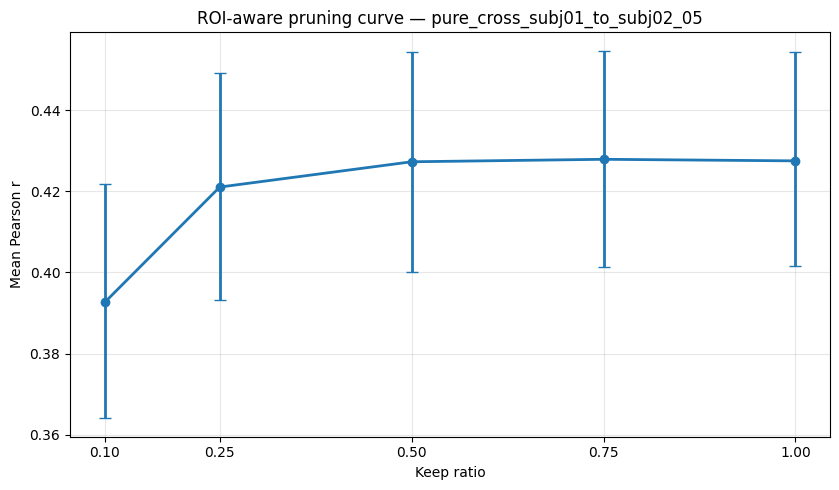

Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/01_roi_aware_curve_within_subj01.png


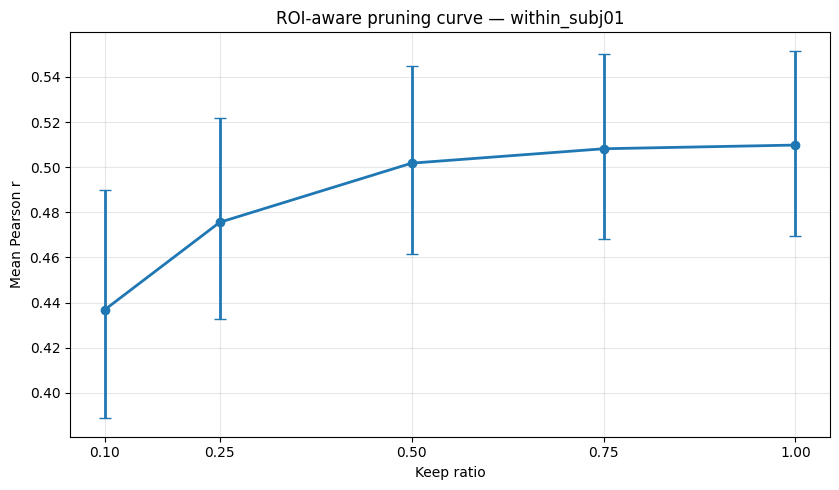

Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/02_roi_aware_retained_performance.csv


,Evaluation,Method,Keep ratio,Mean Pearson r,Full feature baseline Pearson r,Retained full performance (%),Performance loss vs full (%),Mean feature reduction (%)
0,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.10,0.392610,0.427496,91.839460,8.160540,90.07
1,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.25,0.421043,0.427496,98.490549,1.509451,75.00
2,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.50,0.427272,0.427496,99.947560,0.052440,50.00
3,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.75,0.427882,0.427496,100.090355,-0.090355,25.00
4,pure_cross_subj01_to_subj02_05,Full features,1.00,0.427496,0.427496,100.000000,0.000000,0.00
5,within_subj01,ROI-aware pruning,0.10,0.436771,0.509799,85.675027,14.324973,90.07
6,within_subj01,ROI-aware pruning,0.25,0.475571,0.509799,93.285887,6.714113,75.00
7,within_subj01,ROI-aware pruning,0.50,0.501782,0.509799,98.427392,1.572608,50.00
8,within_subj01,ROI-aware pruning,0.75,0.508164,0.509799,99.679277,0.320723,25.00
9,within_subj01,Full features,1.00,0.509799,0.509799,100.000000,0.000000,0.00


Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/02_roi_aware_retained_performance_pure_cross_subj01_to_subj02_05.png


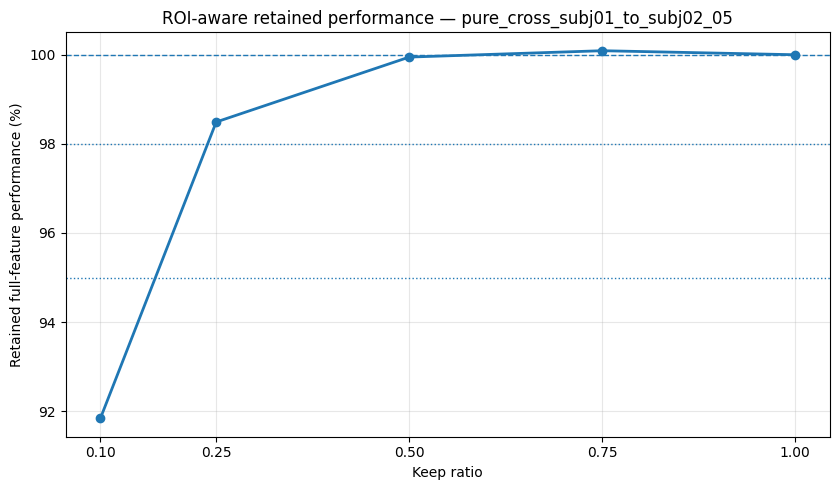

Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/02_roi_aware_retained_performance_within_subj01.png


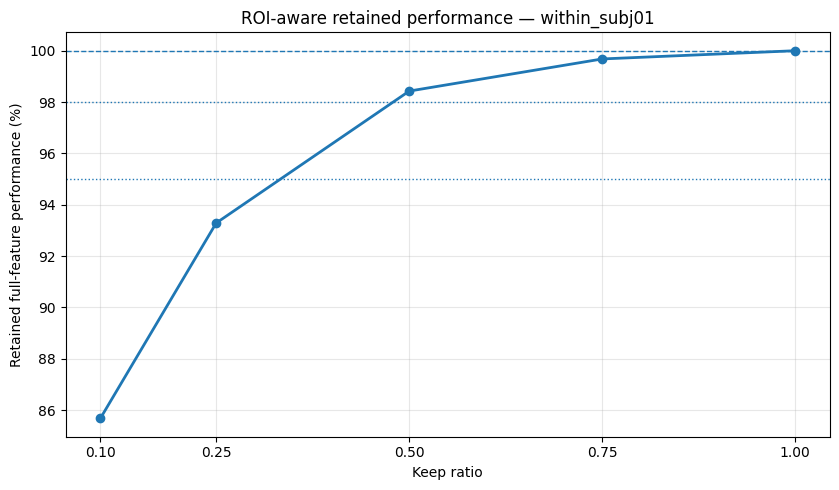

Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/03_backup_best_semantic_threshold_by_method_and_keep_ratio.csv
Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/03_backup_semantic_threshold_grid.csv


/tmp/ipykernel_3836/3536998383.py:405: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ca_summarize_with_ci)


,Evaluation,Method,Keep ratio,Semantic threshold,Mean ± 95% CI,Num configs
0,pure_cross_subj01_to_subj02_05,ROI + semantics-aware pruning,0.10,0.20,"0.3883 [0.3585, 0.4184]",26
1,pure_cross_subj01_to_subj02_05,ROI + semantics-aware pruning,0.25,0.20,"0.4130 [0.3842, 0.4423]",26
2,pure_cross_subj01_to_subj02_05,ROI + semantics-aware pruning,0.50,0.20,"0.4240 [0.3965, 0.4525]",26
3,pure_cross_subj01_to_subj02_05,ROI + semantics-aware pruning,0.75,0.20,"0.4267 [0.3997, 0.4546]",26
4,pure_cross_subj01_to_subj02_05,Semantics-aware pruning,0.10,0.40,"0.3635 [0.3347, 0.3937]",26
5,pure_cross_subj01_to_subj02_05,Semantics-aware pruning,0.25,0.20,"0.4045 [0.3774, 0.4318]",26
6,pure_cross_subj01_to_subj02_05,Semantics-aware pruning,0.50,0.35,"0.4214 [0.3956, 0.4478]",26
7,pure_cross_subj01_to_subj02_05,Semantics-aware pruning,0.75,0.35,"0.4303 [0.4045, 0.4569]",26
8,within_subj01,ROI + semantics-aware pruning,0.10,0.25,"0.4409 [0.3927, 0.4928]",26
9,within_subj01,ROI + semantics-aware pruning,0.25,0.25,"0.4801 [0.4378, 0.5254]",26


Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/03_backup_selected_rows_for_compactness_comparison.csv
Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/03_compactness_performance_line_summary.csv


/tmp/ipykernel_3836/3536998383.py:474: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ca_summarize_with_ci)


,Evaluation,Display method,Keep ratio,Mean feature reduction (%),Mean ± 95% CI,Retained full performance (%),Best semantic threshold,Num configs
0,pure_cross_subj01_to_subj02_05,Full features,1.00,0.00,"0.4275 [0.4015, 0.4542]",100.000000,NaN,26
1,pure_cross_subj01_to_subj02_05,Semantics-aware pruning,0.75,25.00,"0.4303 [0.4045, 0.4569]",100.650564,0.35,26
2,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.75,25.00,"0.4279 [0.4015, 0.4546]",100.090355,NaN,26
3,pure_cross_subj01_to_subj02_05,ROI + semantics-aware pruning,0.75,25.00,"0.4267 [0.3997, 0.4546]",99.812366,0.20,26
4,pure_cross_subj01_to_subj02_05,Random pruning,0.75,25.00,"0.4223 [0.4104, 0.4344]",98.792110,NaN,130
5,pure_cross_subj01_to_subj02_05,Global pruning - variance,0.75,25.00,"0.4156 [0.3860, 0.4455]",97.206669,NaN,26
6,pure_cross_subj01_to_subj02_05,ROI-aware pruning,0.50,50.00,"0.4273 [0.4001, 0.4543]",99.947560,NaN,26
7,pure_cross_subj01_to_subj02_05,ROI + semantics-aware pruning,0.50,50.00,"0.4240 [0.3965, 0.4525]",99.175672,0.20,26
8,pure_cross_subj01_to_subj02_05,Semantics-aware pruning,0.50,50.00,"0.4214 [0.3956, 0.4478]",98.569117,0.35,26
9,pure_cross_subj01_to_subj02_05,Random pruning,0.50,50.00,"0.4060 [0.3934, 0.4177]",94.963059,NaN,130


Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/03_compactness_performance_line_pure_cross_subj01_to_subj02_05.png


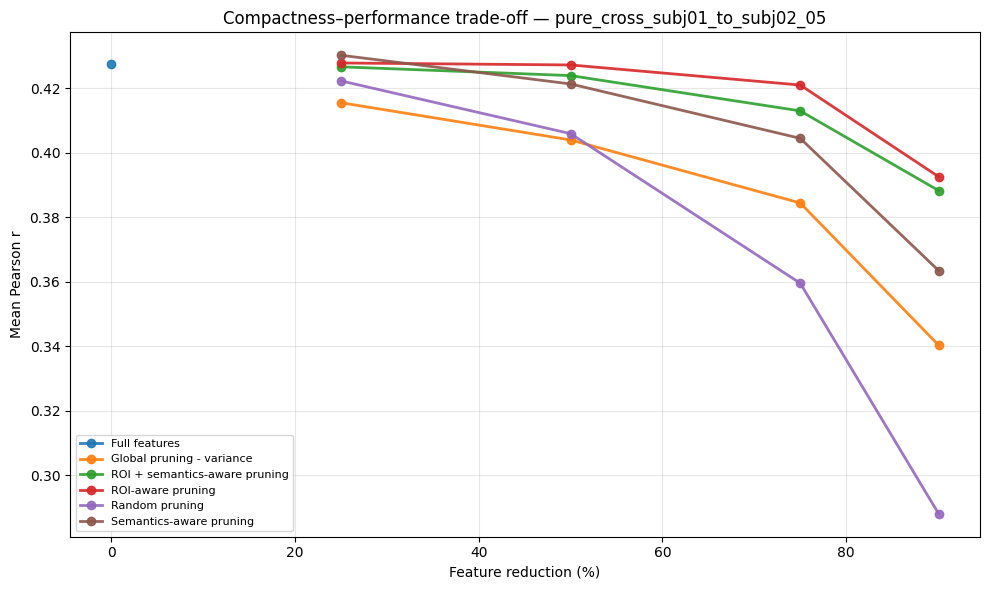

Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/03_compactness_performance_line_within_subj01.png


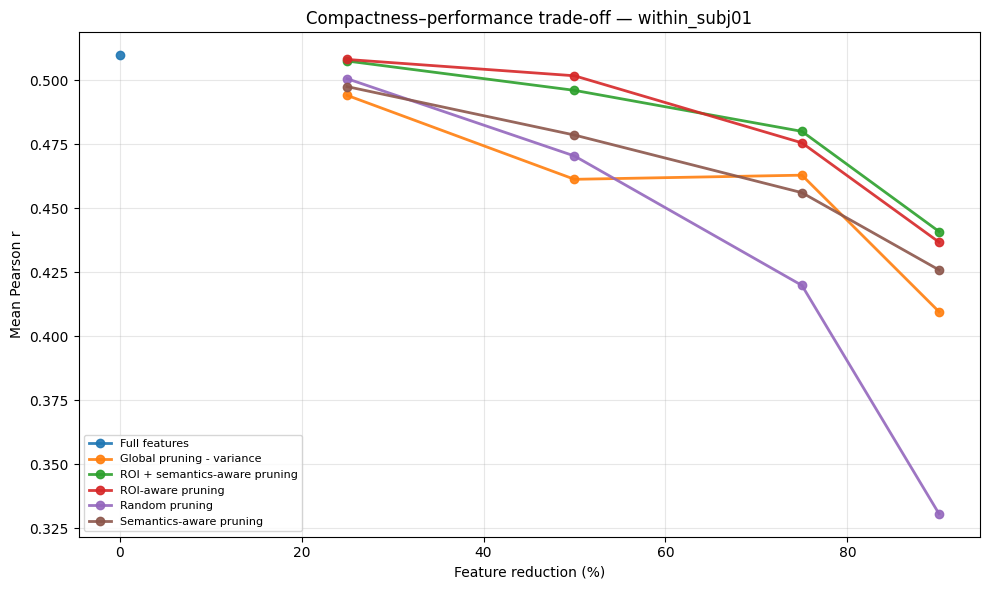

Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/04_roi_by_method_performance_summary.csv


,Evaluation,ROI,Display method,Mean_Pearson_r,Std_Pearson_r,Num_configs
0,pure_cross_subj01_to_subj02_05,FFA-1,Full features,0.530040,0.024969,2
1,pure_cross_subj01_to_subj02_05,FFA-1,Global pruning - variance,0.494014,0.055214,8
2,pure_cross_subj01_to_subj02_05,FFA-1,ROI + semantics-aware pruning,0.521023,0.022246,8
3,pure_cross_subj01_to_subj02_05,FFA-1,ROI-aware pruning,0.522508,0.022948,8
4,pure_cross_subj01_to_subj02_05,FFA-1,Random pruning,0.461181,0.066350,40
5,pure_cross_subj01_to_subj02_05,FFA-1,Semantics-aware pruning,0.505737,0.045874,8
6,pure_cross_subj01_to_subj02_05,FFA-2,Full features,0.481854,0.022204,2
7,pure_cross_subj01_to_subj02_05,FFA-2,Global pruning - variance,0.451067,0.058481,8
8,pure_cross_subj01_to_subj02_05,FFA-2,ROI + semantics-aware pruning,0.473189,0.026807,8
9,pure_cross_subj01_to_subj02_05,FFA-2,ROI-aware pruning,0.475554,0.023917,8


Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/04_roi_by_method_heatmap_pure_cross_subj01_to_subj02_05.png


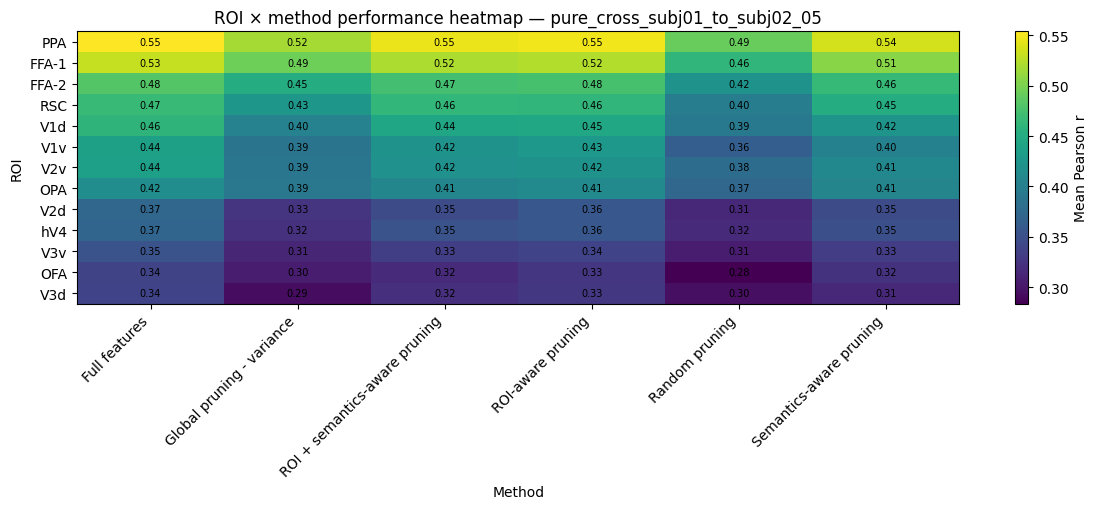

Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/04_roi_by_method_heatmap_within_subj01.png


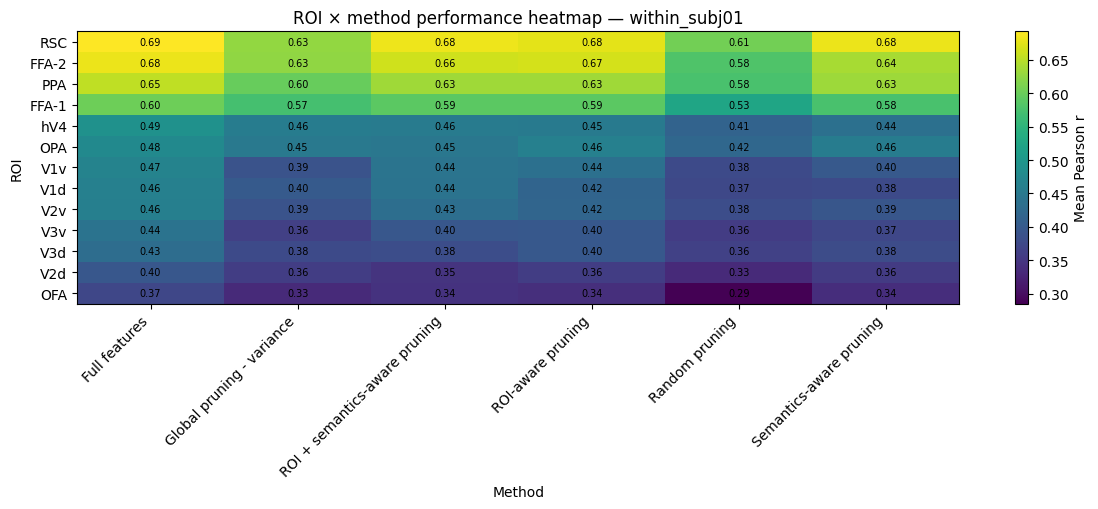

Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/05_semantic_category_by_roi_response_profile.csv
Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/05_backup_best_roi_for_each_semantic_category.csv
Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/05_backup_top3_rois_for_each_semantic_category.csv


,Semantic threshold used,Semantic group,Semantic column,ROI,Num images,Mean ROI z-score,Median ROI z-score,Std ROI z-score
0,0.2,people bodies,sem_people_bodies,V1v,4915,-0.041896,0.019892,1.000204
1,0.2,people bodies,sem_people_bodies,V1d,4915,-0.076969,-0.033015,1.001931
2,0.2,people bodies,sem_people_bodies,V2v,4915,-0.103364,-0.027923,1.016381
3,0.2,people bodies,sem_people_bodies,V2d,4915,-0.128924,-0.086268,0.997077
4,0.2,people bodies,sem_people_bodies,V3v,4915,-0.128249,-0.063683,1.017882
5,0.2,people bodies,sem_people_bodies,V3d,4915,-0.138107,-0.068714,0.998508
6,0.2,people bodies,sem_people_bodies,hV4,4915,-0.141326,-0.095716,1.008234
7,0.2,people bodies,sem_people_bodies,OFA,4915,-0.047162,-0.036492,1.043196
8,0.2,people bodies,sem_people_bodies,FFA-1,4915,0.308583,0.346557,0.951276
9,0.2,people bodies,sem_people_bodies,FFA-2,4915,0.357291,0.438326,0.976484


Saved figure: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/05_semantic_category_by_roi_response_heatmap.png


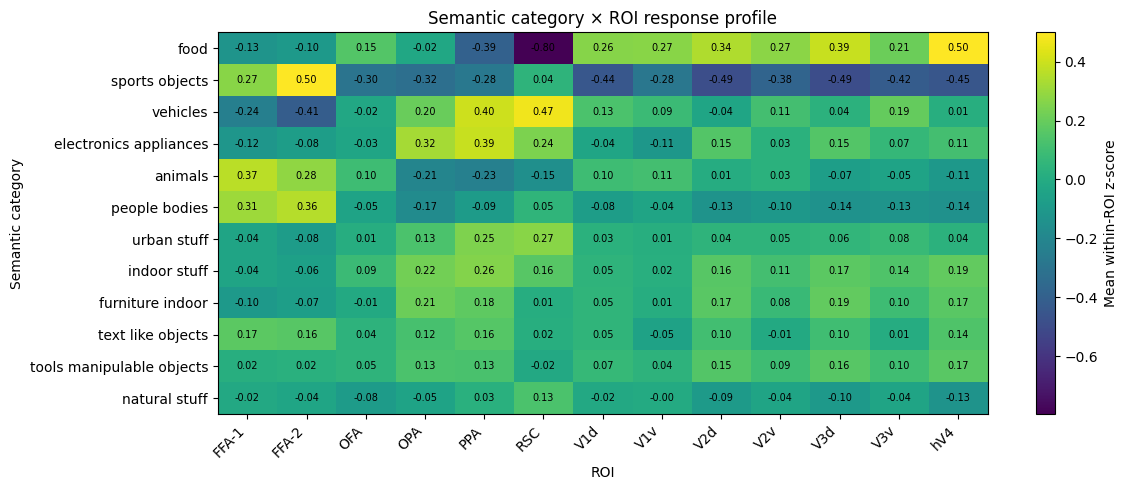

Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/06_backup_random_pruning_seed_level_summary.csv
Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/06_backup_random_pruning_mean_std_across_seeds.csv


,Evaluation,Keep ratio,Random_mean_Pearson_r,Random_std_across_seeds,Num_random_seed_entries,Random mean ± std
0,pure_cross_subj01_to_subj02_05,0.10,0.288074,0.005633,5,0.2881 ± 0.0056
1,pure_cross_subj01_to_subj02_05,0.25,0.359586,0.003330,5,0.3596 ± 0.0033
2,pure_cross_subj01_to_subj02_05,0.50,0.405963,0.004629,5,0.4060 ± 0.0046
3,pure_cross_subj01_to_subj02_05,0.75,0.422332,0.001144,5,0.4223 ± 0.0011
4,within_subj01,0.10,0.330612,0.006113,5,0.3306 ± 0.0061
5,within_subj01,0.25,0.419864,0.005587,5,0.4199 ± 0.0056
6,within_subj01,0.50,0.470437,0.004462,5,0.4704 ± 0.0045
7,within_subj01,0.75,0.500648,0.002742,5,0.5006 ± 0.0027


Saved table: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/07_final_takeaways_summary.csv


,Evaluation,Full features mean Pearson r,ROI-aware 0.50 mean Pearson r,ROI-aware 0.50 retained (%),ROI-aware 0.25 mean Pearson r,ROI-aware 0.25 retained (%),Best semantic configuration,Best semantic mean Pearson r,Best semantic retained (%)
0,pure_cross_subj01_to_subj02_05,0.427496,0.427272,99.947560,0.421043,98.490549,Semantics-aware pruning | keep=0.75 | thr=0.35,0.430277,100.650564
1,within_subj01,0.509799,0.501782,98.427392,0.475571,93.285887,ROI + semantics-aware pruning | keep=0.75 | th...,0.507553,99.559301


Saved Excel workbook: /content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final/clean_v2_comparative_analysis_all_important_tables.xlsx

Clean comparative analysis completed.
All clean V2 CSV tables, figures, and the Excel workbook were saved to:
/content/drive/MyDrive/ComputerVision/algonauts_2023/outputs/comparative_analysis_final


In [38]:
# ============================================================
# COMPARATIVE ANALYSIS — CLEAN VERSION
# ============================================================
#
# Main outputs:
# 1. ROI-aware pruning curve
# 2. ROI-aware retained performance vs full features
# 3. Compactness-performance scatter comparison across methods
# 4. ROI × method performance heatmaps
# 5. Semantic category × ROI response heatmap
#
# Backup tables:
# - Best semantic threshold by method and keep ratio
# - Semantic threshold × keep ratio grid
# - Best/top-3 ROI for each semantic category
# - Random pruning mean ± std across seeds
# - Final takeaways summary
#
# Notes:
# - Files are saved in the same comparative analysis folder.
# - Semantic thresholds are not shown as separate legend entries in the compactness plot.
# - The compactness-performance comparison is shown as a scatter plot, not a line plot.

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

if "OUTPUT_DIR" not in globals():
    raise RuntimeError("OUTPUT_DIR is not defined. Run the notebook setup cells first.")

COMPARATIVE_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "comparative_analysis_final")
os.makedirs(COMPARATIVE_OUTPUT_DIR, exist_ok=True)

print("Clean comparative analysis output directory:")
print(COMPARATIVE_OUTPUT_DIR)


# ------------------------------------------------------------
# Local helpers
# ------------------------------------------------------------

def ca_save_df(df, filename):
    path = os.path.join(COMPARATIVE_OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")
    return path


def ca_save_fig(filename):
    path = os.path.join(COMPARATIVE_OUTPUT_DIR, filename)
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def ca_safe_numeric(df, col):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def ca_safe_filename(text):
    return (
        str(text)
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
        .replace("-", "_")
        .replace(":", "")
        .replace(".", "p")
        .replace("|", "")
        .lower()
    )


def ca_bootstrap_mean_ci(values, n_resamples=2000, ci_level=0.95, random_state=42):
    """
    Bootstrap confidence interval over configuration-level scores.
    This is used only for summary plots/tables, not as a replacement
    for the test-image bootstrap CI computed in the main evaluation.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    if len(values) == 1:
        value = float(values[0])
        return value, value, value

    rng = np.random.default_rng(random_state)
    boot_means = []

    for _ in range(n_resamples):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(sample))

    alpha = 1.0 - ci_level

    mean = float(np.mean(values))
    ci_low = float(np.percentile(boot_means, 100 * alpha / 2))
    ci_high = float(np.percentile(boot_means, 100 * (1 - alpha / 2)))

    return mean, ci_low, ci_high


def ca_summarize_with_ci(group, value_col="Test Mean Pearson r"):
    mean, ci_low, ci_high = ca_bootstrap_mean_ci(
        group[value_col].values,
        n_resamples=2000,
        ci_level=0.95,
        random_state=42,
    )

    selected_features = (
        float(group["Selected features"].mean())
        if "Selected features" in group.columns else np.nan
    )

    total_features = (
        float(group["Total features"].mean())
        if "Total features" in group.columns else np.nan
    )

    if "Feature reduction (%)" in group.columns:
        feature_reduction = float(group["Feature reduction (%)"].mean())
    elif "Keep ratio" in group.columns:
        kr = pd.to_numeric(group["Keep ratio"], errors="coerce").mean()
        feature_reduction = float((1.0 - kr) * 100.0) if pd.notna(kr) else np.nan
    else:
        feature_reduction = np.nan

    keep_ratio = (
        float(pd.to_numeric(group["Keep ratio"], errors="coerce").mean())
        if "Keep ratio" in group.columns else np.nan
    )

    return pd.Series({
        "Mean Pearson r": mean,
        "CI low": ci_low,
        "CI high": ci_high,
        "Mean ± 95% CI": f"{mean:.4f} [{ci_low:.4f}, {ci_high:.4f}]",
        "Std Pearson r": float(group[value_col].std(ddof=1)) if len(group) > 1 else 0.0,
        "Mean selected features": selected_features,
        "Mean total features": total_features,
        "Mean feature reduction (%)": feature_reduction,
        "Mean keep ratio": keep_ratio,
        "Num configs": int(len(group)),
    })


# ------------------------------------------------------------
# Load and validate results dataframe
# ------------------------------------------------------------

if "final_test_results_df" not in globals():
    candidate_paths = sorted(
        glob.glob(os.path.join(OUTPUT_DIR, "**", "*.csv"), recursive=True),
        key=os.path.getmtime,
        reverse=True,
    )

    candidate_paths = [
        p for p in candidate_paths
        if "complete" in os.path.basename(p).lower()
        or "final_test_results" in os.path.basename(p).lower()
        or "all_configurations" in os.path.basename(p).lower()
    ]

    if len(candidate_paths) == 0:
        raise RuntimeError(
            "final_test_results_df is not available and no result CSV was found in OUTPUT_DIR."
        )

    print("Loading results from:")
    print(candidate_paths[0])
    final_test_results_df = pd.read_csv(candidate_paths[0])

results_df = final_test_results_df.copy()

required_cols = ["Evaluation", "Method", "ROI", "Test Mean Pearson r"]
missing_cols = [c for c in required_cols if c not in results_df.columns]

if missing_cols:
    raise RuntimeError(f"Missing required columns in final_test_results_df: {missing_cols}")

for col in [
    "Keep ratio",
    "Semantic threshold",
    "Test Mean Pearson r",
    "Selected features",
    "Total features",
    "Feature reduction (%)",
    "Random seed",
]:
    results_df = ca_safe_numeric(results_df, col)

if "Semantic threshold" not in results_df.columns:
    results_df["Semantic threshold"] = np.nan

if "Keep ratio" in results_df.columns:
    results_df.loc[results_df["Method"] == "Full features", "Keep ratio"] = 1.00

if "Feature reduction (%)" not in results_df.columns and "Keep ratio" in results_df.columns:
    results_df["Feature reduction (%)"] = (1.0 - results_df["Keep ratio"]) * 100.0

ca_save_df(results_df, "00_complete_results_used_for_comparative_analysis.csv")

display(HTML("<h2>Clean comparative analysis V2</h2>"))
display(HTML(
    "<p>This version keeps the most useful outputs for the project narrative. "
    "The compactness-performance comparison is shown as a scatter plot, and semantic thresholds are saved in tables rather than used as separate legend labels.</p>"
))


# ============================================================
# 1. ROI-aware pruning curve
# ============================================================

roi_curve_rows = []

for evaluation_name, eval_df in results_df.groupby("Evaluation"):
    full_df = eval_df[eval_df["Method"] == "Full features"]

    if not full_df.empty:
        stat = ca_summarize_with_ci(full_df)
        row = {
            "Evaluation": evaluation_name,
            "Method": "Full features",
            "Keep ratio": 1.00,
        }
        row.update(stat.to_dict())
        roi_curve_rows.append(row)

    roi_df = eval_df[eval_df["Method"] == "ROI-aware pruning"]

    for keep_ratio, group in roi_df.groupby("Keep ratio"):
        if float(keep_ratio) not in [0.10, 0.25, 0.50, 0.75]:
            continue

        stat = ca_summarize_with_ci(group)
        row = {
            "Evaluation": evaluation_name,
            "Method": "ROI-aware pruning",
            "Keep ratio": float(keep_ratio),
        }
        row.update(stat.to_dict())
        roi_curve_rows.append(row)

roi_aware_curve_df = pd.DataFrame(roi_curve_rows)

if not roi_aware_curve_df.empty:
    roi_aware_curve_df = (
        roi_aware_curve_df
        .sort_values(["Evaluation", "Keep ratio"])
        .reset_index(drop=True)
    )

ca_save_df(roi_aware_curve_df, "01_roi_aware_curve_keep_ratio.csv")

display(HTML("<h3>1. ROI-aware pruning curve</h3>"))

if not roi_aware_curve_df.empty:
    display(roi_aware_curve_df[[
        "Evaluation",
        "Method",
        "Keep ratio",
        "Mean ± 95% CI",
        "Mean feature reduction (%)",
        "Num configs",
    ]])

    for evaluation_name, eval_df in roi_aware_curve_df.groupby("Evaluation"):
        eval_df = eval_df.sort_values("Keep ratio")

        x = eval_df["Keep ratio"].values
        y = eval_df["Mean Pearson r"].values
        yerr_low = y - eval_df["CI low"].values
        yerr_high = eval_df["CI high"].values - y

        plt.figure(figsize=(8.5, 5))
        plt.errorbar(
            x,
            y,
            yerr=[yerr_low, yerr_high],
            marker="o",
            linewidth=2,
            capsize=4,
        )
        plt.xticks([0.10, 0.25, 0.50, 0.75, 1.00])
        plt.xlabel("Keep ratio")
        plt.ylabel("Mean Pearson r")
        plt.title(f"ROI-aware pruning curve — {evaluation_name}")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        ca_save_fig(f"01_roi_aware_curve_{ca_safe_filename(evaluation_name)}.png")
        plt.show()
else:
    print("No ROI-aware pruning curve data available.")


# ============================================================
# 2. ROI-aware retained performance relative to full features
# ============================================================

retained_rows = []

for evaluation_name, eval_df in roi_aware_curve_df.groupby("Evaluation"):
    full_values = eval_df.loc[eval_df["Keep ratio"] == 1.00, "Mean Pearson r"]

    if len(full_values) == 0 or full_values.iloc[0] == 0:
        continue

    full_value = float(full_values.iloc[0])

    temp = eval_df.copy()
    temp["Full feature baseline Pearson r"] = full_value
    temp["Retained full performance (%)"] = temp["Mean Pearson r"] / full_value * 100.0
    temp["Performance loss vs full (%)"] = 100.0 - temp["Retained full performance (%)"]

    retained_rows.append(temp)

roi_aware_retained_df = (
    pd.concat(retained_rows, ignore_index=True)
    if retained_rows else pd.DataFrame()
)

ca_save_df(roi_aware_retained_df, "02_roi_aware_retained_performance.csv")

display(HTML("<h3>2. ROI-aware retained performance relative to full features</h3>"))

if not roi_aware_retained_df.empty:
    display(roi_aware_retained_df[[
        "Evaluation",
        "Method",
        "Keep ratio",
        "Mean Pearson r",
        "Full feature baseline Pearson r",
        "Retained full performance (%)",
        "Performance loss vs full (%)",
        "Mean feature reduction (%)",
    ]])

    for evaluation_name, eval_df in roi_aware_retained_df.groupby("Evaluation"):
        eval_df = eval_df.sort_values("Keep ratio")

        plt.figure(figsize=(8.5, 5))
        plt.plot(
            eval_df["Keep ratio"],
            eval_df["Retained full performance (%)"],
            marker="o",
            linewidth=2,
        )
        plt.axhline(100.0, linestyle="--", linewidth=1)
        plt.axhline(98.0, linestyle=":", linewidth=1)
        plt.axhline(95.0, linestyle=":", linewidth=1)
        plt.xticks([0.10, 0.25, 0.50, 0.75, 1.00])
        plt.xlabel("Keep ratio")
        plt.ylabel("Retained full-feature performance (%)")
        plt.title(f"ROI-aware retained performance — {evaluation_name}")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        ca_save_fig(f"02_roi_aware_retained_performance_{ca_safe_filename(evaluation_name)}.png")
        plt.show()
else:
    print("No retained performance data available.")


# ============================================================
# 3. Compactness-performance comparison across methods
# ============================================================

SEMANTIC_METHODS = [
    "Semantics-aware pruning",
    "ROI + semantics-aware pruning",
]

NON_SEMANTIC_METHODS = [
    "Full features",
    "ROI-aware pruning",
    "Global pruning - variance",
    "Random pruning",
]

semantic_df = results_df[results_df["Method"].isin(SEMANTIC_METHODS)].copy()

if not semantic_df.empty:
    semantic_threshold_summary_df = (
        semantic_df
        .groupby(
            ["Evaluation", "Method", "Keep ratio", "Semantic threshold"],
            dropna=False,
        )
        .apply(ca_summarize_with_ci)
        .reset_index()
    )

    best_semantic_threshold_df = (
        semantic_threshold_summary_df
        .sort_values(
            ["Evaluation", "Method", "Keep ratio", "Mean Pearson r"],
            ascending=[True, True, True, False],
        )
        .groupby(["Evaluation", "Method", "Keep ratio"], dropna=False)
        .head(1)
        .reset_index(drop=True)
    )
else:
    semantic_threshold_summary_df = pd.DataFrame()
    best_semantic_threshold_df = pd.DataFrame()

ca_save_df(best_semantic_threshold_df, "03_backup_best_semantic_threshold_by_method_and_keep_ratio.csv")
ca_save_df(semantic_threshold_summary_df, "03_backup_semantic_threshold_grid.csv")

display(HTML("<h3>3a. Backup: best semantic threshold by method and keep ratio</h3>"))

if not best_semantic_threshold_df.empty:
    display(best_semantic_threshold_df[[
        "Evaluation",
        "Method",
        "Keep ratio",
        "Semantic threshold",
        "Mean ± 95% CI",
        "Num configs",
    ]])
else:
    print("No semantic threshold data available.")

compactness_parts = []

non_semantic_selected = results_df[results_df["Method"].isin(NON_SEMANTIC_METHODS)].copy()
compactness_parts.append(non_semantic_selected)

semantic_selected_parts = []

if not best_semantic_threshold_df.empty:
    for _, row in best_semantic_threshold_df.iterrows():
        mask = (
            (results_df["Evaluation"] == row["Evaluation"]) &
            (results_df["Method"] == row["Method"]) &
            (results_df["Keep ratio"] == row["Keep ratio"]) &
            (results_df["Semantic threshold"] == row["Semantic threshold"])
        )
        semantic_selected_parts.append(results_df[mask].copy())

if semantic_selected_parts:
    compactness_parts.append(pd.concat(semantic_selected_parts, ignore_index=True))

compactness_selected_results_df = pd.concat(compactness_parts, ignore_index=True)

# Clean display name:
# semantic threshold is intentionally not part of the legend.
compactness_selected_results_df["Display method"] = compactness_selected_results_df["Method"].astype(str)

ca_save_df(compactness_selected_results_df, "03_backup_selected_rows_for_compactness_comparison.csv")

compactness_summary_df = (
    compactness_selected_results_df
    .groupby(
        ["Evaluation", "Display method", "Method", "Keep ratio"],
        dropna=False,
    )
    .apply(ca_summarize_with_ci)
    .reset_index()
)

if not best_semantic_threshold_df.empty:
    threshold_lookup_df = best_semantic_threshold_df[[
        "Evaluation",
        "Method",
        "Keep ratio",
        "Semantic threshold",
    ]].drop_duplicates()

    compactness_summary_df = compactness_summary_df.merge(
        threshold_lookup_df,
        on=["Evaluation", "Method", "Keep ratio"],
        how="left",
    )

    compactness_summary_df = compactness_summary_df.rename(
        columns={"Semantic threshold": "Best semantic threshold"}
    )
else:
    compactness_summary_df["Best semantic threshold"] = np.nan

full_baseline_df = (
    compactness_summary_df[compactness_summary_df["Method"] == "Full features"]
    [["Evaluation", "Mean Pearson r"]]
    .rename(columns={"Mean Pearson r": "Full feature baseline Pearson r"})
)

compactness_summary_df = compactness_summary_df.merge(
    full_baseline_df,
    on="Evaluation",
    how="left",
)

compactness_summary_df["Retained full performance (%)"] = (
    compactness_summary_df["Mean Pearson r"] /
    compactness_summary_df["Full feature baseline Pearson r"] *
    100.0
)

compactness_summary_df = (
    compactness_summary_df
    .sort_values(
        ["Evaluation", "Mean feature reduction (%)", "Mean Pearson r"],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)

ca_save_df(compactness_summary_df, "03_compactness_performance_line_summary.csv")

display(HTML("<h3>3b. Compactness-performance comparison across methods</h3>"))
display(HTML(
    "<p>Clean line-plot version. Semantic thresholds are selected per keep ratio and saved in the backup table, "
    "but they are not shown as separate legend entries. Points are connected to show the compactness-performance trend.</p>"
))

display(compactness_summary_df[[
    "Evaluation",
    "Display method",
    "Keep ratio",
    "Mean feature reduction (%)",
    "Mean ± 95% CI",
    "Retained full performance (%)",
    "Best semantic threshold",
    "Num configs",
]])

for evaluation_name, eval_df in compactness_summary_df.groupby("Evaluation"):
    plt.figure(figsize=(10, 6))

    for method_name, method_df in eval_df.groupby("Display method"):
        method_df = method_df.sort_values("Mean feature reduction (%)")

        plt.plot(
            method_df["Mean feature reduction (%)"],
            method_df["Mean Pearson r"],
            marker="o",
            linewidth=2,
            markersize=6,
            alpha=0.9,
            label=method_name,
        )

    plt.xlabel("Feature reduction (%)")
    plt.ylabel("Mean Pearson r")
    plt.title(f"Compactness–performance trade-off — {evaluation_name}")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, loc="best")
    plt.tight_layout()

    ca_save_fig(
        f"03_compactness_performance_line_{ca_safe_filename(evaluation_name)}.png"
    )
    plt.show()

# ============================================================
# 4. ROI × method performance heatmap
# ============================================================

roi_method_summary_df = (
    compactness_selected_results_df
    .groupby(["Evaluation", "ROI", "Display method"], dropna=False)
    .agg(
        Mean_Pearson_r=("Test Mean Pearson r", "mean"),
        Std_Pearson_r=("Test Mean Pearson r", "std"),
        Num_configs=("Test Mean Pearson r", "count"),
    )
    .reset_index()
)

ca_save_df(roi_method_summary_df, "04_roi_by_method_performance_summary.csv")

display(HTML("<h3>4. ROI × method performance summary</h3>"))
display(roi_method_summary_df.head(40))

for evaluation_name, eval_df in roi_method_summary_df.groupby("Evaluation"):
    pivot = eval_df.pivot_table(
        index="ROI",
        columns="Display method",
        values="Mean_Pearson_r",
        aggfunc="mean",
    )

    if pivot.empty:
        continue

    pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

    plt.figure(figsize=(12, max(5, 0.40 * len(pivot.index))))
    im = plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(im, label="Mean Pearson r")

    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Method")
    plt.ylabel("ROI")
    plt.title(f"ROI × method performance heatmap — {evaluation_name}")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.values[i, j]
            if np.isfinite(value):
                plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    ca_save_fig(f"04_roi_by_method_heatmap_{ca_safe_filename(evaluation_name)}.png")
    plt.show()


# ============================================================
# 5. Semantic category × ROI response heatmap
# ============================================================

def ca_to_numpy_array(x):
    try:
        import jax
        return np.asarray(jax.device_get(x))
    except Exception:
        return np.asarray(x)


semantic_roi_profile_df = pd.DataFrame()
semantic_best_roi_df = pd.DataFrame()
semantic_top3_roi_df = pd.DataFrame()

try:
    if "PRIMARY_SEMANTIC_SCORE_THRESHOLD" in globals():
        primary_threshold = float(PRIMARY_SEMANTIC_SCORE_THRESHOLD)
    else:
        primary_threshold = 0.20

    semantic_source_df = None
    semantic_threshold_used = np.nan

    if "raw_train_semantic_groups_by_threshold" in globals():
        available_thresholds = raw_train_semantic_groups_by_threshold

        if primary_threshold in available_thresholds and "subj01" in available_thresholds[primary_threshold]:
            semantic_source_df = available_thresholds[primary_threshold]["subj01"].reset_index(drop=True).copy()
            semantic_threshold_used = primary_threshold
        elif len(available_thresholds) > 0:
            thresholds = sorted(list(available_thresholds.keys()))
            nearest_threshold = min(thresholds, key=lambda x: abs(float(x) - primary_threshold))

            if "subj01" in available_thresholds[nearest_threshold]:
                semantic_source_df = available_thresholds[nearest_threshold]["subj01"].reset_index(drop=True).copy()
                semantic_threshold_used = float(nearest_threshold)

    if semantic_source_df is None and "raw_train_semantic_groups_by_subject" in globals():
        if "subj01" in raw_train_semantic_groups_by_subject:
            semantic_source_df = raw_train_semantic_groups_by_subject["subj01"].reset_index(drop=True).copy()

    if semantic_source_df is None and "SEMANTIC_CACHE_DIR" in globals():
        semantic_cache_candidates = sorted(
            glob.glob(os.path.join(SEMANTIC_CACHE_DIR, "*semantic_groups.csv")),
            key=os.path.getmtime,
            reverse=True,
        )

        if semantic_cache_candidates:
            print("Loading semantic dataframe from cache:")
            print(semantic_cache_candidates[0])
            semantic_source_df = pd.read_csv(semantic_cache_candidates[0]).reset_index(drop=True)

    if semantic_source_df is None:
        raise RuntimeError("No semantic dataframe found.")

    if "SEMANTIC_LABEL_COLUMNS" in globals():
        semantic_cols = [c for c in SEMANTIC_LABEL_COLUMNS if c in semantic_source_df.columns]
    else:
        semantic_cols = [c for c in semantic_source_df.columns if c.startswith("sem_")]

    semantic_cols = [
        c for c in semantic_cols
        if c != "sem_low_level_stuff_textures"
        and not c.endswith("_score")
    ]

    if "all_subjects_fmri" in globals():
        if "AGGREGATED_DATASET_ID" in globals() and AGGREGATED_DATASET_ID in all_subjects_fmri:
            fmri_for_roi_analysis = all_subjects_fmri[AGGREGATED_DATASET_ID]
        elif "subj01" in all_subjects_fmri:
            fmri_for_roi_analysis = all_subjects_fmri["subj01"]
        else:
            first_key = list(all_subjects_fmri.keys())[0]
            fmri_for_roi_analysis = all_subjects_fmri[first_key]
    elif "raw_train_subjects_fmri" in globals():
        if "subj01" in raw_train_subjects_fmri:
            fmri_for_roi_analysis = raw_train_subjects_fmri["subj01"]
        else:
            first_key = list(raw_train_subjects_fmri.keys())[0]
            fmri_for_roi_analysis = raw_train_subjects_fmri[first_key]
    else:
        raise RuntimeError("No fMRI training data found for semantic ROI response analysis.")

    if "TARGET_ROIS" in globals():
        rois_for_profile = [r for r in TARGET_ROIS if r in fmri_for_roi_analysis]
    else:
        rois_for_profile = list(fmri_for_roi_analysis.keys())

    semantic_source_df = semantic_source_df.reset_index(drop=True)
    n_semantic_images = len(semantic_source_df)

    roi_zscores = {}

    for roi in rois_for_profile:
        values = ca_to_numpy_array(fmri_for_roi_analysis[roi]).reshape(-1)

        n = min(len(values), n_semantic_images)
        values = values[:n]

        mean = np.mean(values)
        std = np.std(values)

        if std == 0:
            z_values = np.zeros_like(values, dtype=float)
        else:
            z_values = (values - mean) / std

        roi_zscores[roi] = z_values

    usable_length = min([len(v) for v in roi_zscores.values()] + [n_semantic_images])
    semantic_profile_df = semantic_source_df.iloc[:usable_length].reset_index(drop=True)

    semantic_roi_rows = []

    for sem_col in semantic_cols:
        mask = semantic_profile_df[sem_col].astype(int).values == 1
        n_group = int(mask.sum())

        if n_group == 0:
            continue

        semantic_group = sem_col.replace("sem_", "").replace("_", " ")

        for roi, z_values in roi_zscores.items():
            z_values = z_values[:len(mask)]

            semantic_roi_rows.append({
                "Semantic threshold used": semantic_threshold_used,
                "Semantic group": semantic_group,
                "Semantic column": sem_col,
                "ROI": roi,
                "Num images": n_group,
                "Mean ROI z-score": float(np.mean(z_values[mask])),
                "Median ROI z-score": float(np.median(z_values[mask])),
                "Std ROI z-score": float(np.std(z_values[mask])),
            })

    semantic_roi_profile_df = pd.DataFrame(semantic_roi_rows)

    semantic_best_roi_df = (
        semantic_roi_profile_df
        .sort_values(["Semantic group", "Mean ROI z-score"], ascending=[True, False])
        .groupby("Semantic group")
        .head(1)
        .reset_index(drop=True)
    )

    semantic_top3_roi_df = (
        semantic_roi_profile_df
        .sort_values(["Semantic group", "Mean ROI z-score"], ascending=[True, False])
        .groupby("Semantic group")
        .head(3)
        .reset_index(drop=True)
    )

    ca_save_df(semantic_roi_profile_df, "05_semantic_category_by_roi_response_profile.csv")
    ca_save_df(semantic_best_roi_df, "05_backup_best_roi_for_each_semantic_category.csv")
    ca_save_df(semantic_top3_roi_df, "05_backup_top3_rois_for_each_semantic_category.csv")

    display(HTML("<h3>5. Semantic category × ROI response profile</h3>"))
    display(semantic_roi_profile_df.head(40))

    pivot = semantic_roi_profile_df.pivot_table(
        index="Semantic group",
        columns="ROI",
        values="Mean ROI z-score",
        aggfunc="mean",
    )

    if not pivot.empty:
        pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

        plt.figure(figsize=(12, max(5, 0.40 * len(pivot.index))))
        im = plt.imshow(pivot.values, aspect="auto")
        plt.colorbar(im, label="Mean within-ROI z-score")

        plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.xlabel("ROI")
        plt.ylabel("Semantic category")
        plt.title("Semantic category × ROI response profile")

        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                value = pivot.values[i, j]
                if np.isfinite(value):
                    plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

        plt.tight_layout()
        ca_save_fig("05_semantic_category_by_roi_response_heatmap.png")
        plt.show()

except Exception as e:
    print("Semantic category × ROI response analysis skipped.")
    print("Reason:", repr(e))


# ============================================================
# 6. Backup: random pruning seed summary
# ============================================================

random_summary_df = pd.DataFrame()

random_df = results_df[results_df["Method"] == "Random pruning"].copy()

if not random_df.empty:
    group_cols = ["Evaluation", "Keep ratio"]

    if "Random seed" in random_df.columns:
        group_cols.append("Random seed")
    elif "Seed" in random_df.columns:
        group_cols.append("Seed")

    random_seed_level_df = (
        random_df
        .groupby(group_cols, dropna=False)
        .agg(
            Mean_Pearson_r=("Test Mean Pearson r", "mean"),
            Std_Pearson_r=("Test Mean Pearson r", "std"),
            Num_configs=("Test Mean Pearson r", "count"),
        )
        .reset_index()
    )

    ca_save_df(random_seed_level_df, "06_backup_random_pruning_seed_level_summary.csv")

    random_summary_df = (
        random_seed_level_df
        .groupby(["Evaluation", "Keep ratio"], dropna=False)
        .agg(
            Random_mean_Pearson_r=("Mean_Pearson_r", "mean"),
            Random_std_across_seeds=("Mean_Pearson_r", "std"),
            Num_random_seed_entries=("Mean_Pearson_r", "count"),
        )
        .reset_index()
    )

    random_summary_df["Random mean ± std"] = random_summary_df.apply(
        lambda r: f"{r['Random_mean_Pearson_r']:.4f} ± {r['Random_std_across_seeds']:.4f}"
        if pd.notna(r["Random_std_across_seeds"]) else f"{r['Random_mean_Pearson_r']:.4f}",
        axis=1,
    )

    ca_save_df(random_summary_df, "06_backup_random_pruning_mean_std_across_seeds.csv")

    display(HTML("<h3>Backup: random pruning mean ± std across seeds</h3>"))
    display(random_summary_df)


# ============================================================
# 7. Final takeaways summary
# ============================================================

final_takeaway_rows = []

for evaluation_name, eval_df in results_df.groupby("Evaluation"):
    full_mean = eval_df[eval_df["Method"] == "Full features"]["Test Mean Pearson r"].mean()

    roi_50 = eval_df[
        (eval_df["Method"] == "ROI-aware pruning") &
        (eval_df["Keep ratio"] == 0.50)
    ]["Test Mean Pearson r"].mean()

    roi_25 = eval_df[
        (eval_df["Method"] == "ROI-aware pruning") &
        (eval_df["Keep ratio"] == 0.25)
    ]["Test Mean Pearson r"].mean()

    semantic_candidates = eval_df[eval_df["Method"].isin(SEMANTIC_METHODS)].copy()

    if not semantic_candidates.empty:
        semantic_summary = (
            semantic_candidates
            .groupby(["Method", "Keep ratio", "Semantic threshold"], dropna=False)
            .agg(Mean_Pearson_r=("Test Mean Pearson r", "mean"))
            .reset_index()
            .sort_values("Mean_Pearson_r", ascending=False)
        )

        best_semantic_row = semantic_summary.iloc[0]
        best_semantic_description = (
            f"{best_semantic_row['Method']} | "
            f"keep={best_semantic_row['Keep ratio']:.2f} | "
            f"thr={best_semantic_row['Semantic threshold']:.2f}"
        )
        best_semantic_score = float(best_semantic_row["Mean_Pearson_r"])
    else:
        best_semantic_description = ""
        best_semantic_score = np.nan

    final_takeaway_rows.append({
        "Evaluation": evaluation_name,
        "Full features mean Pearson r": full_mean,
        "ROI-aware 0.50 mean Pearson r": roi_50,
        "ROI-aware 0.50 retained (%)": roi_50 / full_mean * 100 if full_mean != 0 else np.nan,
        "ROI-aware 0.25 mean Pearson r": roi_25,
        "ROI-aware 0.25 retained (%)": roi_25 / full_mean * 100 if full_mean != 0 else np.nan,
        "Best semantic configuration": best_semantic_description,
        "Best semantic mean Pearson r": best_semantic_score,
        "Best semantic retained (%)": best_semantic_score / full_mean * 100 if full_mean != 0 else np.nan,
    })

final_takeaways_df = pd.DataFrame(final_takeaway_rows)

ca_save_df(final_takeaways_df, "07_final_takeaways_summary.csv")

display(HTML("<h3>Final takeaways summary</h3>"))
display(final_takeaways_df)


# ============================================================
# 8. Excel workbook with all important tables
# ============================================================

excel_path = os.path.join(
    COMPARATIVE_OUTPUT_DIR,
    "comparative_analysis_all_important_tables.xlsx"
)

tables_to_export = {
    "complete_results": results_df,
    "roi_aware_curve": roi_aware_curve_df,
    "roi_aware_retained": roi_aware_retained_df,
    "best_semantic_thresholds": best_semantic_threshold_df,
    "semantic_threshold_grid": semantic_threshold_summary_df,
    "compactness_summary": compactness_summary_df,
    "roi_method_summary": roi_method_summary_df,
    "semantic_roi_profile": semantic_roi_profile_df,
    "semantic_best_roi": semantic_best_roi_df,
    "semantic_top3_roi": semantic_top3_roi_df,
    "random_mean_std": random_summary_df,
    "final_takeaways": final_takeaways_df,
}

with pd.ExcelWriter(excel_path) as writer:
    for sheet_name, table in tables_to_export.items():
        if isinstance(table, pd.DataFrame) and not table.empty:
            table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print(f"Saved Excel workbook: {excel_path}")

print("\nClean comparative analysis completed.")
print("All clean V2 CSV tables, figures, and the Excel workbook were saved to:")
print(COMPARATIVE_OUTPUT_DIR)

### Interactive qualitative demo

The following demo displays training images together with their semantic labels and the observed ROI-level fMRI responses. ROI activation is shown as a within-ROI z-score computed over the training images; it is an observed response summary, not a model prediction.


In [39]:
# ============================================================
# INTERACTIVE DEMO: image, semantic labels, category scores, and strongest ROI responses
# ============================================================

import ast
from IPython.display import display, clear_output, HTML
import ipywidgets as widgets

DEMO_SUBJECT = "subj01"
DEMO_THRESHOLD = PRIMARY_SEMANTIC_SCORE_THRESHOLD
DEMO_TOP_ROIS = 5
DEMO_IMAGE_MAX_SIZE = (560, 560)


def demo_parse_score_string(value):
    if value is None or pd.isna(value):
        return {}
    value = str(value).strip()
    if value == "":
        return {}
    out = {}
    for item in value.split("|"):
        if ":" not in item:
            continue
        name, score = item.rsplit(":", 1)
        try:
            out[name.strip()] = float(score)
        except Exception:
            continue
    return out


def demo_semantic_table(row):
    category_scores = demo_parse_score_string(row.get("category_semantic_scores", ""))
    rows = []
    for category_name, score in sorted(category_scores.items(), key=lambda kv: (-kv[1], kv[0])):
        rows.append({
            "COCO category": category_name,
            "semantic score": round(float(score), 4),
        })

    if len(rows) == 0:
        return pd.DataFrame([{"COCO category": "none", "semantic score": 0.0}])
    return pd.DataFrame(rows)


def demo_macro_label_table(row):
    label_cols = get_semantic_label_columns(pd.DataFrame([row]))
    rows = []
    for col in label_cols:
        if int(row.get(col, 0)) == 1:
            rows.append({"Semantic group": col.replace("sem_", "").replace("_", " ")})
    if len(rows) == 0:
        return pd.DataFrame([{"Semantic group": "none"}])
    return pd.DataFrame(rows)


def demo_roi_response_table(row_index):
    roi_rows = []
    fmri_data = all_subjects_fmri[AGGREGATED_DATASET_ID]

    for roi in TARGET_ROIS:
        if roi not in fmri_data:
            continue
        values = onp.asarray(jax.device_get(fmri_data[roi])).reshape(-1)
        if row_index >= len(values):
            continue
        mean = values.mean()
        std = values.std()
        z = 0.0 if std == 0.0 else (values[row_index] - mean) / std
        roi_rows.append({
            "ROI": roi,
            "observed response": round(float(values[row_index]), 4),
            "within-ROI z-score": round(float(z), 4),
        })

    df = pd.DataFrame(roi_rows)
    if df.empty:
        return pd.DataFrame([{"ROI": "none", "observed response": "", "within-ROI z-score": ""}])
    return df.sort_values("within-ROI z-score", ascending=False).head(DEMO_TOP_ROIS).reset_index(drop=True)


def demo_get_image_path(row):
    path = row.get("image_path", "")
    if isinstance(path, str) and os.path.exists(path):
        return path

    filename = row.get("image_filename", "")
    matches = glob.glob(os.path.join(DATA_ROOT, "**", filename), recursive=True)
    if len(matches) == 0:
        raise FileNotFoundError(f"Image not found: {filename}")
    return matches[0]


if not SEMANTIC_GROUPING_ENABLED:
    raise RuntimeError("Semantic grouping is disabled; the demo requires semantic metadata.")

_demo_raw_groups = raw_train_semantic_groups_by_threshold[float(DEMO_THRESHOLD)]
if DEMO_SUBJECT not in _demo_raw_groups:
    raise RuntimeError(f"Subject {DEMO_SUBJECT} not available in semantic groups.")

demo_df = _demo_raw_groups[DEMO_SUBJECT].reset_index(drop=True).copy()
print(f"Demo images available: {len(demo_df)} at threshold {DEMO_THRESHOLD}")

state = {"idx": 0}
out = widgets.Output()

btn_prev = widgets.Button(description="← Previous")
btn_next = widgets.Button(description="Next →")
idx_box = widgets.IntText(value=0, description="Index:")
go_btn = widgets.Button(description="Go", button_style="info")
counter = widgets.HTML()


def render_demo():
    with out:
        clear_output(wait=True)
        idx = max(0, min(state["idx"], len(demo_df) - 1))
        state["idx"] = idx
        idx_box.value = idx
        counter.value = f"<b>Image {idx + 1} / {len(demo_df)}</b>"

        row = demo_df.iloc[idx]
        image_path = demo_get_image_path(row)
        img = Image.open(image_path).convert("RGB")
        img.thumbnail(DEMO_IMAGE_MAX_SIZE)

        display(HTML(f"<h3>{row.get('image_filename', '')}</h3>"))
        display(img)

        display(HTML("<h4>Assigned semantic groups</h4>"))
        display(demo_macro_label_table(row))

        display(HTML("<h4>Visible COCO categories kept after threshold</h4>"))
        display(demo_semantic_table(row))

        display(HTML("<h4>Most responsive ROIs for this training image</h4>"))
        display(demo_roi_response_table(idx))

        metadata = pd.DataFrame({
            "field": ["threshold", "semantic source", "nsd id", "coco id", "crop box"],
            "value": [
                row.get("semantic_score_threshold", DEMO_THRESHOLD),
                row.get("semantic_source", ""),
                row.get("nsd_id", ""),
                row.get("coco_id", ""),
                row.get("cropBox", ""),
            ],
        })
        display(HTML("<h4>Metadata</h4>"))
        display(metadata)


def go_prev(_):
    state["idx"] = max(0, state["idx"] - 1)
    render_demo()


def go_next(_):
    state["idx"] = min(len(demo_df) - 1, state["idx"] + 1)
    render_demo()


def go_to(_):
    state["idx"] = max(0, min(int(idx_box.value), len(demo_df) - 1))
    render_demo()


btn_prev.on_click(go_prev)
btn_next.on_click(go_next)
go_btn.on_click(go_to)

controls = widgets.HBox([btn_prev, btn_next, idx_box, go_btn])
display(widgets.VBox([counter, controls, out]))
render_demo()


Demo images available: 9841 at threshold 0.2


## Final protocol summary

The notebook implements a training-time semantics-guided feature-pruning protocol for brain-aligned visual encoding.

- **Training source:** `subj01`, training split.
- **Evaluation protocols:** within-subject (`subj01` → `subj01`) and pure cross-subject (`subj01` → `subj02`-`subj05`).
- **Targets:** ROI-averaged fMRI responses.
- **Visual representations:** frozen DINOv2 and CLIP features.
- **Semantic metadata:** cropped COCO panoptic masks aligned to NSD/Algonauts stimuli.
- **Semantic thresholds:** 0.20, 0.25, 0.30, 0.35, and 0.40.
- **Baselines:** full features, global variance pruning, random pruning with multiple seeds, ROI-aware pruning, semantics-aware pruning, and ROI+semantics-aware pruning.
- **Statistical reporting:** bootstrap confidence intervals and random-pruning mean ± standard deviation.
- **Main interpretation:** the strongest expected evidence is the compactness-performance trade-off, especially whether ROI-aware or ROI+semantic pruning can preserve full-feature performance with substantially fewer features.
